# Notebook Hyperparameter Tuning BERTopic vs LDA

Notebook ini dipakai untuk eksperimen tuning parameter secara terkontrol di environment fastAPI yang sama dengan aplikasi utama.

## 1. Setup Environment dan Import Library
Import library utama, atur random seed, dan tetapkan path kerja agar artefak tuning tersimpan konsisten.

Setup environment lokal (tanpa remote container):
```bash
cd fastapi
bash scripts/setup_local_notebook_env.sh
```
Catatan: script akan memprioritaskan `python3.11`. Jika tidak ada, script fallback ke `python3` dengan warning mismatch versi.

In [2]:
import itertools
import json
import os
import random
import sys
import time
from datetime import datetime
from importlib import metadata as importlib_metadata
from pathlib import Path

# Hindari warning permission matplotlib saat kernel jalan di container/non-root.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
except Exception:
    sns = None

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

CWD = Path.cwd()
if (CWD / "app").exists():
    FASTAPI_ROOT = CWD
elif (CWD.parent / "app").exists():
    FASTAPI_ROOT = CWD.parent
else:
    raise RuntimeError("Jalankan notebook dari folder fastapi atau subfolder di dalamnya.")

if str(FASTAPI_ROOT) not in sys.path:
    sys.path.insert(0, str(FASTAPI_ROOT))

ARTIFACTS_DIR = FASTAPI_ROOT / "data" / "results" / "artifacts_tuning"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

from gensim.corpora import Dictionary
from IPython.display import display

from app.ml.bertopic_trainer import BERTopicTrainer
from app.ml.evaluator import TopicEvaluator
from app.ml.hyperparameters import BERTOPIC_GRID, BERTOPIC_PRESETS, LDA_GRID, LDA_PRESETS
from app.ml.lda_trainer import LDATrainer
from app.models.schemas import BERTopicHyperparameters, HDBSCANHyperparameters, LDAHyperparameters, UMAPHyperparameters
from app.services.preprocessing import TextPreprocessor

pd.set_option("display.max_columns", 200)
print("FASTAPI_ROOT:", FASTAPI_ROOT)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)
print("PYTHON_EXECUTABLE:", sys.executable)
print("PYTHON_VERSION:", sys.version.split()[0])

expected_python = (3, 11)
if sys.version_info[:2] != expected_python:
    print(
        f"WARNING: Notebook masih jalan di Python {sys.version_info.major}.{sys.version_info.minor}. "
        f"Disarankan Python {expected_python[0]}.{expected_python[1]} agar hasil konsisten dengan FastAPI container."
    )
    print("\nLangkah pindah kernel ke Python 3.11:")
    print("1. cd fastapi")
    print("2. PYTHON_BIN=python3.11 bash scripts/setup_local_notebook_env.sh")
    print("3. Pilih kernel: FastAPI Local (Py3.11)")

expected_versions = {
    "torch": "2.11.0+cpu",
    "numpy": "1.26.4",
    "pandas": "2.2.3",
    "bertopic": "0.16.4",
    "sentence-transformers": "3.3.1",
    "hdbscan": "0.8.40",
    "umap-learn": "0.5.7",
    "gensim": "4.3.3",
}

version_mismatch = []
for package_name, expected_version in expected_versions.items():
    try:
        installed_version = importlib_metadata.version(package_name)
    except importlib_metadata.PackageNotFoundError:
        version_mismatch.append((package_name, expected_version, "not-installed"))
        continue

    if installed_version != expected_version:
        version_mismatch.append((package_name, expected_version, installed_version))

if version_mismatch:
    print("WARNING: Ada versi paket yang tidak sama dengan environment FastAPI container:")
    for pkg, expected, installed in version_mismatch:
        print(f"- {pkg}: expected={expected}, installed={installed}")
else:
    print("Versi Python & paket utama sudah selaras dengan FastAPI container.")

FASTAPI_ROOT: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi
ARTIFACTS_DIR: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/artifacts_tuning
PYTHON_EXECUTABLE: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/.venv-fastapi-notebook-py311/bin/python
PYTHON_VERSION: 3.11.15
Versi Python & paket utama sudah selaras dengan FastAPI container.


## 2. Load Dataset, Normalisasi Kolom Raw, dan Validasi Skema Teks
Muat dataset dari local file, normalisasi nama kolom raw (mis. `Judul` -> `title`, `Abstrak` -> `abstract`, `Kesimpulan` -> `conclusion`), bersihkan teks dasar, lalu tampilkan statistik awal.

In [3]:
DATA_SOURCE_CANDIDATES = [
    FASTAPI_ROOT / "data" / "processed" / "preprocessed_data.csv",
    FASTAPI_ROOT / "data" / "processed" / "processed_data.csv",
    FASTAPI_ROOT / "data" / "processed" / "topic_model_dataset.csv",
]
RAW_DATA_PATH = FASTAPI_ROOT / "data" / "raw" / "raw_data.csv"


def load_source_dataframe():
    for candidate in DATA_SOURCE_CANDIDATES:
        if candidate.exists():
            print(f"Loaded processed data: {candidate}")
            return pd.read_csv(candidate), candidate

    if RAW_DATA_PATH.exists():
        print(f"Loaded raw data: {RAW_DATA_PATH}")
        return pd.read_csv(RAW_DATA_PATH), RAW_DATA_PATH

    raise FileNotFoundError("Tidak menemukan file data processed maupun raw_data.csv")


def normalize_raw_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    normalized_map = {}
    for col in df.columns:
        normalized = str(col).strip().lower()
        normalized = normalized.replace("%", "pct")
        normalized = "".join(ch if ch.isalnum() else "_" for ch in normalized)
        while "__" in normalized:
            normalized = normalized.replace("__", "_")
        normalized = normalized.strip("_")
        normalized_map[col] = normalized or "col"

    df = df.rename(columns=normalized_map)

    def coalesce(target_col: str, aliases: list[str]):
        existing = [c for c in aliases if c in df.columns]
        if not existing:
            return

        merged = pd.Series("", index=df.index, dtype="object")
        for col_name in existing:
            values = df[col_name].fillna("").astype(str).str.strip()
            empty_mask = merged.str.strip() == ""
            merged.loc[empty_mask] = values.loc[empty_mask]
        df[target_col] = merged

    coalesce("id", ["id"])
    coalesce("title", ["title", "judul"])
    coalesce("author", ["author", "penulis"])
    coalesce("year", ["year", "tahun"])
    coalesce("abstract", ["abstract", "abstrak"])
    coalesce("conclusion", ["conclusion", "kesimpulan"])
    coalesce("keywords", ["keywords", "kata_kunci"])
    coalesce("url", ["url"])

    for col_name in ["title", "abstract", "conclusion"]:
        if col_name in df.columns:
            df[col_name] = (
                df[col_name]
                .fillna("")
                .astype(str)
                .str.replace(r"\s+", " ", regex=True)
                .str.replace(r"(?i)^(nan|none|null|tidak tersedia|-)$", "", regex=True)
                .str.strip()
            )

    if "year" in df.columns:
        df["year"] = (
            df["year"]
            .fillna("")
            .astype(str)
            .str.extract(r"(\d{4})", expand=False)
        )

    return df


source_df, source_path = load_source_dataframe()
source_df = normalize_raw_columns(source_df)

if "url" in source_df.columns:
    source_df = source_df.drop_duplicates(subset=["url"], keep="first")

text_candidates = ["combined_text", "cleaned_text", "processed_text", "abstract"]
text_col_for_validation = next((c for c in text_candidates if c in source_df.columns), None)
if text_col_for_validation is None:
    raise ValueError(
        "Dataset tidak punya kolom teks. Minimal salah satu dari: combined_text, cleaned_text, processed_text, abstract/abstrak"
    )

source_df[text_col_for_validation] = source_df[text_col_for_validation].fillna("").astype(str)
source_df[text_col_for_validation] = source_df[text_col_for_validation].str.replace(r"\s+", " ", regex=True).str.strip()

source_df = source_df[source_df[text_col_for_validation] != ""].copy()
source_df = source_df[source_df[text_col_for_validation].str.len() >= 30].copy()
source_df = source_df.drop_duplicates(subset=[text_col_for_validation]).reset_index(drop=True)

source_df["id"] = range(1, len(source_df) + 1)

if "year" in source_df.columns:
    source_df["year"] = pd.to_numeric(source_df["year"], errors="coerce").astype("Int64")

text_lengths = source_df[text_col_for_validation].str.split().apply(len)

summary_df = pd.DataFrame(
    {
        "metric": [
            "n_documents",
            "min_len",
            "mean_len",
            "median_len",
            "max_len",
        ],
        "value": [
            len(source_df),
            int(text_lengths.min()),
            round(float(text_lengths.mean()), 2),
            round(float(text_lengths.median()), 2),
            int(text_lengths.max()),
        ],
    }
)

print("Sumber data aktif:", source_path)
display(summary_df)

preview_cols = [c for c in ["id", "title", "year", "abstract", "conclusion"] if c in source_df.columns]
if preview_cols:
    display(source_df[preview_cols].head(3))
else:
    display(source_df.head(3))

Loaded raw data: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/raw/raw_data.csv
Sumber data aktif: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/raw/raw_data.csv


,metric,value
0,n_documents,473.00
1,min_len,54.00
2,mean_len,165.14
3,median_len,161.00
4,max_len,302.00


,id,title,year,abstract,conclusion
0,1,"Perbandingan Metode Grid Search, Random Search...",2026,Layanan perpajakan digital Website Coretax yan...,Berdasarkan hasil penelitian yang telah dilaku...
1,2,Klasterisasi Produktivitas Pertanian di Kabupa...,2026,Produktivitas pertanian padi merupakan aspek p...,"Berdasarkan hasil penelitian, perancangan, dan..."
2,3,Implementasi Algoritma Holt-Winters Exponentia...,2026,Kunjungan wisatawan pada destinasi wisata cend...,Berdasarkan hasil penelitian mengenai implemen...


## 3. Preprocessing Teks Konsisten untuk BERTopic dan LDA
Bangun preprocessing reusable untuk menghasilkan corpus BERTopic (cleaned_text) dan corpus LDA (processed_text + dictionary/corpus). Jika input masih raw, notebook otomatis generate dua kolom tersebut dari title-abstract-conclusion yang sudah dinormalisasi.

In [4]:
preprocessor = TextPreprocessor(
    remove_stopwords=True,
    use_stemming=True,
    min_word_length=3,
    language="indonesian",
)


def ensure_dual_preprocessing(df: pd.DataFrame):
    df = df.copy()

    # Bersihkan kolom teks dasar dulu untuk semua jalur input (processed maupun raw).
    for col_name in ["title", "abstract", "conclusion", "cleaned_text", "processed_text"]:
        if col_name in df.columns:
            df[col_name] = (
                df[col_name]
                .fillna("")
                .astype(str)
                .str.replace(r"\s+", " ", regex=True)
                .str.strip()
            )

    has_cleaned = "cleaned_text" in df.columns
    has_processed = "processed_text" in df.columns

    if has_cleaned and has_processed:
        df = df[(df["cleaned_text"] != "") & (df["processed_text"] != "")].reset_index(drop=True)
        return df, "existing_dual_columns"

    if "abstract" not in df.columns:
        raise ValueError(
            "Dataset raw belum punya kolom abstrak. Pastikan ada kolom `Abstrak` atau `abstract` sebelum preprocessing."
        )

    generated = preprocessor.preprocess_dataframe(
        df,
        text_column="abstract",
        title_column="title",
        conclusion_column="conclusion",
    )

    generated["cleaned_text"] = generated["cleaned_text"].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    generated["processed_text"] = generated["processed_text"].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    generated = generated[(generated["cleaned_text"] != "") & (generated["processed_text"] != "")].reset_index(drop=True)

    return generated, "generated_from_raw"


working_df, preprocessing_source = ensure_dual_preprocessing(source_df)

if "id" not in working_df.columns:
    working_df["id"] = range(1, len(working_df) + 1)
working_df["id"] = working_df["id"].astype(int)

if "year" in working_df.columns:
    working_df["year"] = pd.to_numeric(working_df["year"], errors="coerce").astype("Int64")

bertopic_docs = working_df["cleaned_text"].tolist()
lda_docs = working_df["processed_text"].tolist()

tokenized_lda_docs = [doc.split() for doc in lda_docs]
lda_dictionary = Dictionary(tokenized_lda_docs)
lda_corpus = [lda_dictionary.doc2bow(doc) for doc in tokenized_lda_docs]

if "year" in working_df.columns and working_df["year"].notna().all():
    timestamps = working_df["year"].astype(int).tolist()
else:
    timestamps = None

document_ids = working_df["id"].astype(int).tolist()

print("Preprocessing source:", preprocessing_source)
print("Jumlah dokumen BERTopic:", len(bertopic_docs))
print("Jumlah dokumen LDA:", len(lda_docs))
print("Ukuran dictionary LDA:", len(lda_dictionary))
print("Timestamps tersedia:", timestamps is not None)

preview_cols = [c for c in ["id", "title", "year", "cleaned_text", "processed_text"] if c in working_df.columns]
display(working_df[preview_cols].head(2))

2026-04-12 16:36:35.513 | INFO     | app.services.preprocessing:preprocess_dataframe:161 - Preprocessing 473 documents (dual pipeline)...
2026-04-12 16:36:35.514 | INFO     | app.services.preprocessing:preprocess_dataframe:175 -   Building combined_text (title + abstract + optional conclusion)...
2026-04-12 16:36:35.650 | INFO     | app.services.preprocessing:preprocess_dataframe:181 -   [BERTopic pipeline] Soft clean (no stopword removal, no stemming)...
2026-04-12 16:36:35.786 | INFO     | app.services.preprocessing:preprocess_dataframe:184 -   [LDA pipeline] Full clean + stopword removal + stemming...
2026-04-12 16:46:24.530 | INFO     | app.services.preprocessing:preprocess_dataframe:200 - Preprocessing complete. 473 documents remaining.
2026-04-12 16:46:24.544 | INFO     | app.services.preprocessing:preprocess_dataframe:201 -   cleaned_text avg words: 285.1
2026-04-12 16:46:24.551 | INFO     | app.services.preprocessing:preprocess_dataframe:204 -   processed_text avg words: 160.6


Preprocessing source: generated_from_raw
Jumlah dokumen BERTopic: 473
Jumlah dokumen LDA: 473
Ukuran dictionary LDA: 5402
Timestamps tersedia: True


,id,title,year,cleaned_text,processed_text
0,1,"Perbandingan Metode Grid Search, Random Search...",2026,"perbandingan metode grid search, random search...",banding grid search random search bayesian opt...
1,2,Klasterisasi Produktivitas Pertanian di Kabupa...,2026,klasterisasi produktivitas pertanian di kabupa...,klasterisasi produktivitas tani kabupaten bata...


## 4. Definisi Search Space Hyperparameter BERTopic (Mode Eksperimental)
Tetapkan skenario BERTopic dari preset dan/atau grid agar eksperimen bisa dilooping.

Mode eksperimen aktif di notebook ini memaksa:
- jumlah topik target minimal 8 (`nr_topics >= 8`)
- batas atas topik agar hasil tidak berlebihan (`nr_topics <= 12`)
- menyertakan opsi `nr_topics="auto"` pada skenario grid agar hasil auto bisa dibandingkan langsung
- ekstraksi keyword minimal 15 kata per topik (`top_n_words >= 15`)

In [5]:
SCENARIO_MODE = "both"  # opsi: presets, grid, both
MAX_BERTOPIC_GRID_SCENARIOS = 6
SCENARIO_RANDOM_SEED = 42

# Constraint eksperimen: target topik minimal 8, maksimal 12, dan keyword minimal 15.
EXPERIMENTAL_MIN_TOPICS = 8
EXPERIMENTAL_MAX_TOPICS = 12
ALLOW_NR_TOPICS_AUTO = True
EXPERIMENTAL_NR_TOPICS_CANDIDATES = [8, 10, 12, "auto"]

EXPERIMENTAL_MIN_TOP_WORDS = 15
EXPERIMENTAL_MIN_TOPIC_SIZE = 8
ENFORCE_EXPERIMENTAL_CONSTRAINTS = True


def build_grid_combinations(grid_dict):
    keys = list(grid_dict.keys())
    value_lists = [grid_dict[k] for k in keys]
    return [dict(zip(keys, values)) for values in itertools.product(*value_lists)]


def sample_combinations(combos, max_items, seed):
    if max_items is None or max_items >= len(combos):
        return combos
    rng = random.Random(seed)
    return rng.sample(combos, k=max_items)


def _safe_int(value, fallback):
    try:
        return int(value)
    except Exception:
        try:
            return int(float(str(value).strip()))
        except Exception:
            return fallback


def _normalize_nr_topics_value(value):
    if isinstance(value, str):
        nr_text = value.strip().lower()
        if nr_text in {"", "none", "null"}:
            return EXPERIMENTAL_MIN_TOPICS
        if nr_text == "auto":
            return "auto" if ALLOW_NR_TOPICS_AUTO else EXPERIMENTAL_MIN_TOPICS
        value = _safe_int(nr_text, EXPERIMENTAL_MIN_TOPICS)
    elif value is None:
        return EXPERIMENTAL_MIN_TOPICS

    numeric_value = _safe_int(value, EXPERIMENTAL_MIN_TOPICS)
    numeric_value = max(EXPERIMENTAL_MIN_TOPICS, numeric_value)
    if EXPERIMENTAL_MAX_TOPICS is not None:
        numeric_value = min(int(EXPERIMENTAL_MAX_TOPICS), numeric_value)
    return numeric_value


def normalize_combo_for_experiment(combo):
    normalized = dict(combo)

    if not ENFORCE_EXPERIMENTAL_CONSTRAINTS:
        return normalized

    normalized["nr_topics"] = _normalize_nr_topics_value(
        normalized.get("nr_topics", EXPERIMENTAL_MIN_TOPICS)
    )
    normalized["top_n_words"] = max(
        EXPERIMENTAL_MIN_TOP_WORDS,
        _safe_int(normalized.get("top_n_words", EXPERIMENTAL_MIN_TOP_WORDS), EXPERIMENTAL_MIN_TOP_WORDS),
    )
    normalized["min_topic_size"] = max(
        EXPERIMENTAL_MIN_TOPIC_SIZE,
        _safe_int(normalized.get("min_topic_size", EXPERIMENTAL_MIN_TOPIC_SIZE), EXPERIMENTAL_MIN_TOPIC_SIZE),
    )
    return normalized


def build_working_bertopic_grid():
    grid = {}
    for key, value in BERTOPIC_GRID.items():
        if isinstance(value, list):
            grid[key] = list(value)
        elif isinstance(value, tuple):
            grid[key] = [value]
        else:
            grid[key] = [value]

    if not ENFORCE_EXPERIMENTAL_CONSTRAINTS:
        return grid

    nr_topics_values = [
        _normalize_nr_topics_value(value)
        for value in EXPERIMENTAL_NR_TOPICS_CANDIDATES
    ]
    nr_topics_values = list(dict.fromkeys(nr_topics_values))
    if not nr_topics_values:
        nr_topics_values = [EXPERIMENTAL_MIN_TOPICS]
    grid["nr_topics"] = nr_topics_values

    min_topic_size_values = [
        _safe_int(value, EXPERIMENTAL_MIN_TOPIC_SIZE)
        for value in grid.get("min_topic_size", [EXPERIMENTAL_MIN_TOPIC_SIZE])
    ]
    grid["min_topic_size"] = sorted(
        set(max(EXPERIMENTAL_MIN_TOPIC_SIZE, value) for value in min_topic_size_values)
    )

    top_n_words_values = [
        _safe_int(value, EXPERIMENTAL_MIN_TOP_WORDS)
        for value in grid.get("top_n_words", [EXPERIMENTAL_MIN_TOP_WORDS])
    ]
    grid["top_n_words"] = sorted(
        set(max(EXPERIMENTAL_MIN_TOP_WORDS, value) for value in top_n_words_values)
    )

    return grid


def enforce_experimental_constraints_on_params(params: BERTopicHyperparameters) -> BERTopicHyperparameters:
    if not ENFORCE_EXPERIMENTAL_CONSTRAINTS:
        return params

    constrained = normalize_combo_for_experiment(params.model_dump())
    return BERTopicHyperparameters(**constrained)


def bertopic_params_from_combo(combo):
    combo = normalize_combo_for_experiment(combo)

    return BERTopicHyperparameters(
        embedding_model="denaya/indoSBERT-large",
        min_topic_size=combo["min_topic_size"],
        nr_topics=combo["nr_topics"],
        top_n_words=combo["top_n_words"],
        n_gram_range=list(combo["vectorizer_ngram_range"]),
        vectorizer_min_df=combo["vectorizer_min_df"],
        vectorizer_max_df=combo["vectorizer_max_df"],
        embedding_batch_size=16,
        seed=42,
        umap_params=UMAPHyperparameters(
            n_neighbors=combo["umap_n_neighbors"],
            n_components=combo["umap_n_components"],
            min_dist=combo["umap_min_dist"],
            metric=combo["umap_metric"],
            random_state=42,
        ),
        hdbscan_params=HDBSCANHyperparameters(
            min_cluster_size=combo["hdbscan_min_cluster_size"],
            min_samples=combo["hdbscan_min_samples"],
            cluster_selection_method=combo["hdbscan_cluster_selection_method"],
        ),
    )


bertopic_scenarios = []
all_bertopic_grid = []
sampled_bertopic_grid = []
working_bertopic_grid = build_working_bertopic_grid()

if SCENARIO_MODE in {"presets", "both"}:
    for preset_name, preset_value in BERTOPIC_PRESETS.items():
        preset_params = enforce_experimental_constraints_on_params(
            preset_value.model_copy(deep=True)
        )

        bertopic_scenarios.append(
            {
                "scenario_id": f"bertopic_preset_{preset_name}",
                "source": "preset",
                "params": preset_params,
                "meta": {"preset_name": preset_name},
            }
        )

if SCENARIO_MODE in {"grid", "both"}:
    all_bertopic_grid = build_grid_combinations(working_bertopic_grid)
    sampled_bertopic_grid = sample_combinations(
        all_bertopic_grid,
        MAX_BERTOPIC_GRID_SCENARIOS,
        SCENARIO_RANDOM_SEED,
    )

    if ALLOW_NR_TOPICS_AUTO and sampled_bertopic_grid:
        has_auto = any(
            str(combo.get("nr_topics", "")).strip().lower() == "auto"
            for combo in sampled_bertopic_grid
        )
        if not has_auto:
            auto_combo = next(
                (
                    combo
                    for combo in all_bertopic_grid
                    if str(combo.get("nr_topics", "")).strip().lower() == "auto"
                ),
                None,
            )
            if auto_combo is not None:
                sampled_bertopic_grid = [auto_combo] + sampled_bertopic_grid
                sampled_bertopic_grid = sampled_bertopic_grid[
                    :max(1, MAX_BERTOPIC_GRID_SCENARIOS)
                ]

    for idx, combo in enumerate(sampled_bertopic_grid, start=1):
        bertopic_scenarios.append(
            {
                "scenario_id": f"bertopic_grid_{idx:03d}",
                "source": "grid",
                "params": bertopic_params_from_combo(combo),
                "meta": combo,
            }
        )

print("BERTopic total scenarios:", len(bertopic_scenarios))
print("BERTopic total grid combinations:", len(all_bertopic_grid))
if ENFORCE_EXPERIMENTAL_CONSTRAINTS:
    print(
        "Eksperimental constraints aktif:",
        f"nr_topics>={EXPERIMENTAL_MIN_TOPICS},",
        f"nr_topics<={EXPERIMENTAL_MAX_TOPICS},",
        f"top_n_words>={EXPERIMENTAL_MIN_TOP_WORDS},",
        f"min_topic_size>={EXPERIMENTAL_MIN_TOPIC_SIZE}",
    )
    print("Kandidat nr_topics eksplorasi:", working_bertopic_grid.get("nr_topics"))

bertopic_preview = pd.DataFrame(
    [
        {
            "scenario_id": s["scenario_id"],
            "source": s["source"],
            "nr_topics": s["params"].nr_topics,
            "top_n_words": s["params"].top_n_words,
            "min_topic_size": s["params"].min_topic_size,
            "meta": str(s["meta"]),
        }
        for s in bertopic_scenarios
    ]
)
display(bertopic_preview.head(15))

BERTopic total scenarios: 9
BERTopic total grid combinations: 3888
Eksperimental constraints aktif: nr_topics>=8, nr_topics<=12, top_n_words>=15, min_topic_size>=8
Kandidat nr_topics eksplorasi: [8, 10, 12, 'auto']


,scenario_id,source,nr_topics,top_n_words,min_topic_size,meta
0,bertopic_preset_default,preset,8,15,10,{'preset_name': 'default'}
1,bertopic_preset_fine_grained,preset,8,15,10,{'preset_name': 'fine_grained'}
2,bertopic_preset_coarse,preset,10,15,20,{'preset_name': 'coarse'}
3,bertopic_grid_001,grid,10,15,10,"{'umap_n_neighbors': 70, 'umap_n_components': ..."
4,bertopic_grid_002,grid,10,15,10,"{'umap_n_neighbors': 40, 'umap_n_components': ..."
5,bertopic_grid_003,grid,10,15,12,"{'umap_n_neighbors': 40, 'umap_n_components': ..."
6,bertopic_grid_004,grid,8,15,12,"{'umap_n_neighbors': 70, 'umap_n_components': ..."
7,bertopic_grid_005,grid,12,15,10,"{'umap_n_neighbors': 40, 'umap_n_components': ..."
8,bertopic_grid_006,grid,auto,15,12,"{'umap_n_neighbors': 40, 'umap_n_components': ..."


## 5. Definisi Search Space Hyperparameter LDA
Tetapkan skenario LDA yang sebanding agar perbandingan dengan BERTopic adil.

In [6]:
MAX_LDA_GRID_SCENARIOS = 12


def lda_params_from_combo(combo):
    return LDAHyperparameters(
        num_topics=combo["num_topics"],
        passes=combo["passes"],
        iterations=combo["iterations"],
        chunksize=100,
        random_state=42,
        alpha=combo["alpha"],
        eta=combo["eta"],
        no_below=combo["no_below"],
        no_above=combo["no_above"],
    )


lda_scenarios = []
all_lda_grid = []
sampled_lda_grid = []

if SCENARIO_MODE in {"presets", "both"}:
    for preset_name, preset_value in LDA_PRESETS.items():
        lda_scenarios.append(
            {
                "scenario_id": f"lda_preset_{preset_name}",
                "source": "preset",
                "params": preset_value.model_copy(deep=True),
                "meta": {"preset_name": preset_name},
            }
        )

if SCENARIO_MODE in {"grid", "both"}:
    all_lda_grid = build_grid_combinations(LDA_GRID)
    sampled_lda_grid = sample_combinations(all_lda_grid, MAX_LDA_GRID_SCENARIOS, SCENARIO_RANDOM_SEED)

    for idx, combo in enumerate(sampled_lda_grid, start=1):
        lda_scenarios.append(
            {
                "scenario_id": f"lda_grid_{idx:03d}",
                "source": "grid",
                "params": lda_params_from_combo(combo),
                "meta": combo,
            }
        )

print("LDA total scenarios:", len(lda_scenarios))
print("LDA total grid combinations:", len(all_lda_grid))

lda_preview = pd.DataFrame(
    [{"scenario_id": s["scenario_id"], "source": s["source"], "meta": str(s["meta"])} for s in lda_scenarios]
)
display(lda_preview.head(10))

LDA total scenarios: 15
LDA total grid combinations: 24


,scenario_id,source,meta
0,lda_preset_default,preset,{'preset_name': 'default'}
1,lda_preset_more_topics,preset,{'preset_name': 'more_topics'}
2,lda_preset_fewer_topics,preset,{'preset_name': 'fewer_topics'}
3,lda_grid_001,grid,"{'num_topics': 12, 'passes': 20, 'iterations':..."
4,lda_grid_002,grid,"{'num_topics': 8, 'passes': 10, 'iterations': ..."
5,lda_grid_003,grid,"{'num_topics': 8, 'passes': 10, 'iterations': ..."
6,lda_grid_004,grid,"{'num_topics': 10, 'passes': 10, 'iterations':..."
7,lda_grid_005,grid,"{'num_topics': 8, 'passes': 20, 'iterations': ..."
8,lda_grid_006,grid,"{'num_topics': 12, 'passes': 10, 'iterations':..."
9,lda_grid_007,grid,"{'num_topics': 8, 'passes': 20, 'iterations': ..."


## 6. Fungsi Evaluasi Topik (Coherence, Diversity, dan Runtime)
Buat evaluator terstandar agar hasil BERTopic dan LDA bisa dibandingkan di tabel yang sama.

In [7]:
evaluator = TopicEvaluator()


def safe_json_dumps(obj):
    return json.dumps(obj, ensure_ascii=False, default=str)


def evaluate_bertopic_run(trainer, docs, train_result):
    metrics = evaluator.evaluate_bertopic(
        model=trainer.model,
        documents=docs,
        topics=trainer.topics,
        vectorizer_model=trainer.vectorizer_model,
        coherence_type=trainer.params.coherence_type,
        coherence_tokenization=trainer.params.coherence_tokenization,
        coherence_dict_no_below=trainer.params.coherence_dict_no_below,
        coherence_dict_no_above=trainer.params.coherence_dict_no_above,
        top_n_words=trainer.params.top_n_words,
    )

    objective_score = float(metrics.get("score_cv_td", metrics.get("score", 0.0)) or 0.0)

    return {
        "coherence_cv": metrics.get("coherence_cv"),
        "topic_diversity": metrics.get("topic_diversity"),
        "objective_score": objective_score,
        "raw_score": metrics.get("score"),
        "score_cv_td": metrics.get("score_cv_td"),
        "score_hmean_cv_td": metrics.get("score_hmean_cv_td"),
        "num_topics": metrics.get("num_topics", train_result.get("num_topics")),
        "num_outliers": metrics.get("num_outliers", train_result.get("num_outliers")),
        "outlier_pct": metrics.get("outlier_pct"),
        "runtime_seconds": train_result.get("training_duration_seconds"),
    }


def evaluate_lda_run(trainer, train_result):
    metrics = evaluator.evaluate_lda(
        model=trainer.model,
        tokenized_docs=trainer.tokenized_docs,
        dictionary=trainer.dictionary,
    )

    objective_score = float(metrics.get("score", 0.0) or 0.0)

    return {
        "coherence_cv": metrics.get("coherence_cv"),
        "topic_diversity": metrics.get("topic_diversity"),
        "objective_score": objective_score,
        "raw_score": metrics.get("score"),
        "num_topics": metrics.get("num_topics", train_result.get("num_topics")),
        "runtime_seconds": train_result.get("training_duration_seconds"),
    }

## 7. Loop Hyperparameter Tuning untuk BERTopic
Jalankan seluruh skenario BERTopic, hitung metrik, tangani exception per eksperimen, lalu simpan hasil antar-run.

In [8]:
# Knob eksperimen BERTopic (cukup ubah di cell ini)
# - two_stage_rerank: screening tanpa reduce_outliers + rerank top-K dengan reduce_outliers
# - one_pass_full: satu kali run sesuai parameter skenario (termasuk reduce_outliers default)
# - one_pass_no_reduce: satu kali run semua skenario dengan reduce_outliers dimatikan
BERTOPIC_SELECTION_MODE = "two_stage_rerank"

# Dipakai hanya saat mode two_stage_rerank aktif
BERTOPIC_RERANK_TOP_K = 5

In [9]:
bertopic_rows = []
best_bertopic_payload = None
bertopic_started = time.time()
bertopic_success_payloads = []

RUN_DTA_PER_SCENARIO_BERTOPIC = False

allowed_selection_modes = {
    "two_stage_rerank",
    "one_pass_full",
    "one_pass_no_reduce",
}
selection_mode_raw = str(globals().get("BERTOPIC_SELECTION_MODE", "two_stage_rerank")).strip().lower()
if selection_mode_raw not in allowed_selection_modes:
    print(
        f"[WARN] BERTOPIC_SELECTION_MODE={selection_mode_raw!r} tidak valid. "
        "Fallback ke 'two_stage_rerank'."
    )
    selection_mode_raw = "two_stage_rerank"

selection_mode = selection_mode_raw
rerank_top_k = max(1, int(globals().get("BERTOPIC_RERANK_TOP_K", 5)))

use_two_stage_bertopic_rerank = selection_mode == "two_stage_rerank"
disable_reduce_outliers_in_stage1 = selection_mode in {"two_stage_rerank", "one_pass_no_reduce"}
stage1_label = "screening" if use_two_stage_bertopic_rerank else "single_pass"

if use_two_stage_bertopic_rerank:
    print(
        f"Mode BERTopic: {selection_mode}. "
        f"Screening tanpa reduce_outliers + rerank top-{rerank_top_k} dengan reduce_outliers aktif."
    )
elif selection_mode == "one_pass_no_reduce":
    print("Mode BERTopic: one_pass_no_reduce. Semua skenario dijalankan sekali tanpa reduce_outliers.")
else:
    print("Mode BERTopic: one_pass_full. Semua skenario dijalankan sekali sesuai parameter skenario.")

bertopic_train_timestamps = timestamps if RUN_DTA_PER_SCENARIO_BERTOPIC else None
if not RUN_DTA_PER_SCENARIO_BERTOPIC and timestamps is not None:
    print("DTA per skenario BERTopic dinonaktifkan. DTA akan dijalankan sekali untuk best BERTopic setelah tuning.")

embedding_model_name = (
    bertopic_scenarios[0]["params"].embedding_model
    if bertopic_scenarios
    else "denaya/indoSBERT-large"
)
embedding_cache_key = (
    embedding_model_name,
    len(bertopic_docs),
    bertopic_docs[0] if bertopic_docs else "",
    bertopic_docs[-1] if bertopic_docs else "",
)

if "bertopic_shared_embeddings_cache" not in globals():
    bertopic_shared_embeddings_cache = {}

shared_embeddings = bertopic_shared_embeddings_cache.get(embedding_cache_key)

if bertopic_scenarios:
    if shared_embeddings is None:
        print("Menghitung shared embeddings untuk semua skenario BERTopic...")
        embedding_trainer = BERTopicTrainer(params=bertopic_scenarios[0]["params"])
        shared_embeddings = embedding_trainer.compute_embeddings(bertopic_docs)
        bertopic_shared_embeddings_cache[embedding_cache_key] = shared_embeddings
        print("Embeddings shape:", shared_embeddings.shape)
    else:
        print("Menggunakan shared embeddings dari cache:", shared_embeddings.shape)

# Stage 1 / single-pass
for idx, scenario in enumerate(bertopic_scenarios, start=1):
    scenario_id = scenario["scenario_id"]
    base_params = scenario["params"]
    params_stage1 = base_params.model_copy(deep=True)

    if disable_reduce_outliers_in_stage1:
        params_stage1.reduce_outliers = False

    print(f"[BERTopic {stage1_label.upper()} {idx}/{len(bertopic_scenarios)}] {scenario_id}")

    row = {
        "model": "BERTopic",
        "scenario_id": scenario_id,
        "scenario_source": scenario["source"],
        "stage": stage1_label,
        "selection_mode": selection_mode,
        "reduce_outliers_active": bool(params_stage1.reduce_outliers),
        "screening_objective_score": None,
        "status": "ok",
    }

    try:
        trainer = BERTopicTrainer(params=params_stage1)
        train_result = trainer.train(
            documents=bertopic_docs,
            embeddings=shared_embeddings,
            timestamps=bertopic_train_timestamps,
            document_ids=document_ids,
        )

        metrics_payload = evaluate_bertopic_run(trainer, bertopic_docs, train_result)

        row.update(metrics_payload)
        row["params"] = safe_json_dumps(params_stage1.model_dump())
        row["scenario_meta"] = safe_json_dumps(scenario["meta"])

        bertopic_success_payloads.append(
            {
                "objective_score": float(row.get("objective_score", 0.0) or 0.0),
                "trainer": trainer,
                "scenario": scenario,
                "params_used": params_stage1,
                "train_result": train_result,
                "metrics": metrics_payload,
                "stage": stage1_label,
            }
        )

    except Exception as exc:
        row["status"] = "failed"
        row["error"] = str(exc)
        row["params"] = safe_json_dumps(params_stage1.model_dump())
        row["scenario_meta"] = safe_json_dumps(scenario["meta"])

        print("  gagal:", exc)

    bertopic_rows.append(row)

# Stage 2 (optional): rerank top-K stage-1
if use_two_stage_bertopic_rerank:
    stage1_ok_payloads = [
        payload
        for payload in bertopic_success_payloads
        if payload.get("stage") == stage1_label
    ]
    stage1_ok_payloads.sort(
        key=lambda payload: float(payload.get("objective_score", 0.0) or 0.0),
        reverse=True,
    )

    rerank_count = min(rerank_top_k, len(stage1_ok_payloads))
    if rerank_count == 0:
        print("Rerank dilewati: tidak ada hasil stage-1 BERTopic yang sukses.")
    else:
        print(f"Rerank {rerank_count} skenario teratas dengan reduce_outliers aktif...")
        rerank_targets = stage1_ok_payloads[:rerank_count]

        for rerank_idx, target_payload in enumerate(rerank_targets, start=1):
            scenario = target_payload["scenario"]
            scenario_id = scenario["scenario_id"]
            params_final = scenario["params"].model_copy(deep=True)
            params_final.reduce_outliers = True

            print(f"[BERTopic RERANK {rerank_idx}/{rerank_count}] {scenario_id}")

            row = {
                "model": "BERTopic",
                "scenario_id": scenario_id,
                "scenario_source": scenario["source"],
                "stage": "rerank_reduce_outliers",
                "selection_mode": selection_mode,
                "reduce_outliers_active": bool(params_final.reduce_outliers),
                "screening_objective_score": float(target_payload.get("objective_score", 0.0) or 0.0),
                "status": "ok",
            }

            try:
                trainer = BERTopicTrainer(params=params_final)
                train_result = trainer.train(
                    documents=bertopic_docs,
                    embeddings=shared_embeddings,
                    timestamps=bertopic_train_timestamps,
                    document_ids=document_ids,
                )

                metrics_payload = evaluate_bertopic_run(trainer, bertopic_docs, train_result)

                row.update(metrics_payload)
                row["params"] = safe_json_dumps(params_final.model_dump())
                row["scenario_meta"] = safe_json_dumps(scenario["meta"])

                bertopic_success_payloads.append(
                    {
                        "objective_score": float(row.get("objective_score", 0.0) or 0.0),
                        "trainer": trainer,
                        "scenario": scenario,
                        "params_used": params_final,
                        "train_result": train_result,
                        "metrics": metrics_payload,
                        "stage": "rerank_reduce_outliers",
                    }
                )

            except Exception as exc:
                row["status"] = "failed"
                row["error"] = str(exc)
                row["params"] = safe_json_dumps(params_final.model_dump())
                row["scenario_meta"] = safe_json_dumps(scenario["meta"])
                print("  gagal:", exc)

            bertopic_rows.append(row)

preferred_stage = "rerank_reduce_outliers" if use_two_stage_bertopic_rerank else stage1_label
preferred_pool = [
    payload
    for payload in bertopic_success_payloads
    if payload.get("stage") == preferred_stage
]

if not preferred_pool:
    preferred_stage = stage1_label
    preferred_pool = [
        payload
        for payload in bertopic_success_payloads
        if payload.get("stage") == stage1_label
    ]

if preferred_pool:
    best_bertopic_payload = max(
        preferred_pool,
        key=lambda payload: float(payload.get("objective_score", 0.0) or 0.0),
    )
    print(
        "Best BERTopic final pool:",
        preferred_stage,
        "->",
        best_bertopic_payload["scenario"]["scenario_id"],
        f"(score={float(best_bertopic_payload['objective_score']):.6f})",
    )
else:
    print("Tidak ada skenario BERTopic yang sukses.")

bertopic_results_df = pd.DataFrame(bertopic_rows)
if not bertopic_results_df.empty:
    if "objective_score" in bertopic_results_df.columns:
        bertopic_results_df["objective_score"] = pd.to_numeric(
            bertopic_results_df["objective_score"], errors="coerce"
        )
    if "screening_objective_score" in bertopic_results_df.columns:
        bertopic_results_df["screening_objective_score"] = pd.to_numeric(
            bertopic_results_df["screening_objective_score"], errors="coerce"
        )

    if "stage" in bertopic_results_df.columns:
        stage_order = {
            "rerank_reduce_outliers": 0,
            "single_pass": 1,
            "screening": 2,
        }
        bertopic_results_df["stage_priority"] = (
            bertopic_results_df["stage"].map(stage_order).fillna(99).astype(int)
        )
        bertopic_results_df = bertopic_results_df.sort_values(
            ["stage_priority", "objective_score"],
            ascending=[True, False],
            na_position="last",
        ).reset_index(drop=True)
        bertopic_results_df = bertopic_results_df.drop(columns=["stage_priority"])
    elif "objective_score" in bertopic_results_df.columns:
        bertopic_results_df = bertopic_results_df.sort_values(
            "objective_score", ascending=False, na_position="last"
        ).reset_index(drop=True)

bertopic_elapsed = time.time() - bertopic_started
print(f"BERTopic tuning selesai dalam {bertopic_elapsed / 60:.2f} menit")
display(bertopic_results_df.head(15))

2026-04-12 16:46:24.849 | INFO     | app.ml.bertopic_trainer:compute_embeddings:334 - Computing sentence embeddings for 473 documents using denaya/indoSBERT-large...
2026-04-12 16:46:24.851 | INFO     | app.ml.bertopic_trainer:_build_embedding_model:175 - Loading sentence encoder: denaya/indoSBERT-large (IndoBERT-large + Siamese Network, output: 256-dim)


Mode BERTopic: two_stage_rerank. Screening tanpa reduce_outliers + rerank top-5 dengan reduce_outliers aktif.
DTA per skenario BERTopic dinonaktifkan. DTA akan dijalankan sekali untuk best BERTopic setelah tuning.
Menghitung shared embeddings untuk semua skenario BERTopic...


Batches: 100%|██████████| 30/30 [07:56<00:00, 15.89s/it]
2026-04-12 16:54:26.643 | INFO     | app.ml.bertopic_trainer:compute_embeddings:367 - Embeddings shape: (473, 256) (dim=256)
2026-04-12 16:54:26.644 | INFO     | app.ml.bertopic_trainer:train:389 - Starting BERTopic training on 473 documents
2026-04-12 16:54:26.645 | INFO     | app.ml.bertopic_trainer:train:390 - Embedding model: denaya/indoSBERT-large (256-dim)


Embeddings shape: (473, 256)
[BERTopic SCREENING 1/9] bertopic_preset_default


2026-04-12 16:54:27.736 | INFO     | app.ml.bertopic_trainer:train:393 - Reproducibility settings applied with seed=42
2026-04-12 16:54:27.739 | INFO     | app.ml.bertopic_trainer:_build_embedding_model:175 - Loading sentence encoder: denaya/indoSBERT-large (IndoBERT-large + Siamese Network, output: 256-dim)
2026-04-12 16:54:37.105 | INFO     | app.ml.bertopic_trainer:_build_model:323 - BERTopic model pipeline built successfully
2026-04-12 16:54:37.107 | INFO     | app.ml.bertopic_trainer:train:403 - Fitting BERTopic model (UMAP → HDBSCAN → c-TF-IDF + MMR)...
2026-04-12 16:54:37,190 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-12 16:54:55,438 - BERTopic - Dimensionality - Completed ✓
2026-04-12 16:54:55,440 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-12 16:54:55,482 - BERTopic - Cluster - Completed ✓
2026-04-12 16:54:55,483 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-0

...

2026-04-12 17:13:06.979 | INFO     | app.ml.bertopic_trainer:_build_model:323 - BERTopic model pipeline built successfully
2026-04-12 17:13:06.982 | INFO     | app.ml.bertopic_trainer:train:403 - Fitting BERTopic model (UMAP → HDBSCAN → c-TF-IDF + MMR)...
2026-04-12 17:13:06,991 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-12 17:13:07,871 - BERTopic - Dimensionality - Completed ✓
2026-04-12 17:13:07,872 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-12 17:13:08,008 - BERTopic - Cluster - Completed ✓
2026-04-12 17:13:08,008 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-04-12 17:13:57,666 - BERTopic - Representation - Completed ✓
2026-04-12 17:13:57,667 - BERTopic - Topic reduction - Reducing number of topics
2026-04-12 17:14:16,339 - BERTopic - Topic reduction - Reduced number of topics from 21 to 8
2026-04-12 17:14:16.470 | INFO     | app.ml.bertopic_trainer:train:420 - Out

[BERTopic RERANK 5/5] bertopic_preset_default


2026-04-12 17:14:42.885 | INFO     | app.ml.bertopic_trainer:_build_model:323 - BERTopic model pipeline built successfully
2026-04-12 17:14:42.888 | INFO     | app.ml.bertopic_trainer:train:403 - Fitting BERTopic model (UMAP → HDBSCAN → c-TF-IDF + MMR)...
2026-04-12 17:14:42,892 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-12 17:14:43,834 - BERTopic - Dimensionality - Completed ✓
2026-04-12 17:14:43,835 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-12 17:14:43,850 - BERTopic - Cluster - Completed ✓
2026-04-12 17:14:43,851 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-04-12 17:15:29,751 - BERTopic - Representation - Completed ✓
2026-04-12 17:15:29,752 - BERTopic - Topic reduction - Reducing number of topics
2026-04-12 17:15:48,576 - BERTopic - Topic reduction - Reduced number of topics from 19 to 8
2026-04-12 17:15:48.714 | INFO     | app.ml.bertopic_trainer:train:420 - Out

Best BERTopic final pool: rerank_reduce_outliers -> bertopic_grid_002 (score=0.641390)
BERTopic tuning selesai dalam 29.76 menit


,model,scenario_id,scenario_source,stage,selection_mode,reduce_outliers_active,screening_objective_score,status,coherence_cv,topic_diversity,objective_score,raw_score,score_cv_td,score_hmean_cv_td,num_topics,num_outliers,outlier_pct,runtime_seconds,params,scenario_meta
0,BERTopic,bertopic_grid_002,grid,rerank_reduce_outliers,two_stage_rerank,True,0.510148,ok,0.4722,0.9556,0.641390,0.451234,0.641390,0.632069,9,0,0.00,106.03,"{""embedding_model"": ""denaya/indoSBERT-large"", ...","{""umap_n_neighbors"": 40, ""umap_n_components"": ..."
1,BERTopic,bertopic_grid_004,grid,rerank_reduce_outliers,two_stage_rerank,True,0.456824,ok,0.5161,0.8714,0.639110,0.448785,0.639110,0.648259,7,1,0.21,89.04,"{""embedding_model"": ""denaya/indoSBERT-large"", ...","{""umap_n_neighbors"": 70, ""umap_n_components"": ..."
2,BERTopic,bertopic_preset_fine_grained,preset,rerank_reduce_outliers,two_stage_rerank,True,0.447542,ok,0.4713,0.8857,0.616340,0.417430,0.616340,0.615225,7,0,0.00,94.79,"{""embedding_model"": ""denaya/indoSBERT-large"", ...","{""preset_name"": ""fine_grained""}"
3,BERTopic,bertopic_grid_001,grid,rerank_reduce_outliers,two_stage_rerank,True,0.475367,ok,0.4100,0.9222,0.589270,0.378102,0.589270,0.567635,9,0,0.00,99.23,"{""embedding_model"": ""denaya/indoSBERT-large"", ...","{""umap_n_neighbors"": 70, ""umap_n_components"": ..."
4,BERTopic,bertopic_preset_default,preset,rerank_reduce_outliers,two_stage_rerank,True,0.427085,ok,0.3257,0.9714,0.551695,0.316385,0.551695,0.487834,7,0,0.00,91.59,"{""embedding_model"": ""denaya/indoSBERT-large"", ...","{""preset_name"": ""default""}"
5,BERTopic,bertopic_grid_002,grid,screening,two_stage_rerank,False,NaN,ok,0.5022,0.9667,0.510148,0.372555,0.510148,0.661007,9,110,23.26,79.23,"{""embedding_model"": ""denaya/indoSBERT-large"", ...","{""umap_n_neighbors"": 40, ""umap_n_components"": ..."
6,BERTopic,bertopic_grid_001,grid,screening,two_stage_rerank,False,NaN,ok,0.4557,0.9333,0.475367,0.324593,0.475367,0.612390,9,112,23.68,72.55,"{""embedding_model"": ""denaya/indoSBERT-large"", ...","{""umap_n_neighbors"": 70, ""umap_n_components"": ..."
7,BERTopic,bertopic_grid_004,grid,screening,two_stage_rerank,False,NaN,ok,0.4234,0.9429,0.456824,0.301334,0.456824,0.584387,7,116,24.52,65.37,"{""embedding_model"": ""denaya/indoSBERT-large"", ...","{""umap_n_neighbors"": 70, ""umap_n_components"": ..."
8,BERTopic,bertopic_preset_fine_grained,preset,screening,two_stage_rerank,False,NaN,ok,0.4563,0.8857,0.447542,0.298178,0.447542,0.602302,7,124,26.22,75.69,"{""embedding_model"": ""denaya/indoSBERT-large"", ...","{""preset_name"": ""fine_grained""}"
9,BERTopic,bertopic_preset_default,preset,screening,two_stage_rerank,False,NaN,ok,0.3804,0.9286,0.427085,0.263623,0.427085,0.539709,7,120,25.37,283.32,"{""embedding_model"": ""denaya/indoSBERT-large"", ...","{""preset_name"": ""default""}"


## 8. Loop Hyperparameter Tuning untuk LDA
Jalankan skenario LDA dengan prosedur evaluasi yang sama, lalu urutkan berdasarkan objective utama.

In [10]:
lda_rows = []
best_lda_payload = None
lda_started = time.time()

for idx, scenario in enumerate(lda_scenarios, start=1):
    scenario_id = scenario["scenario_id"]
    params = scenario["params"]

    print(f"[LDA {idx}/{len(lda_scenarios)}] {scenario_id}")

    row = {
        "model": "LDA",
        "scenario_id": scenario_id,
        "scenario_source": scenario["source"],
        "status": "ok",
    }

    try:
        trainer = LDATrainer(params=params)
        train_result = trainer.train(documents=lda_docs, timestamps=timestamps)

        metrics_payload = evaluate_lda_run(trainer, train_result)

        row.update(metrics_payload)
        row["params"] = safe_json_dumps(params.model_dump())
        row["scenario_meta"] = safe_json_dumps(scenario["meta"])

        if (best_lda_payload is None) or (row["objective_score"] > best_lda_payload["objective_score"]):
            best_lda_payload = {
                "objective_score": row["objective_score"],
                "trainer": trainer,
                "scenario": scenario,
                "train_result": train_result,
                "metrics": metrics_payload,
            }

    except Exception as exc:
        row["status"] = "failed"
        row["error"] = str(exc)
        row["params"] = safe_json_dumps(params.model_dump())
        row["scenario_meta"] = safe_json_dumps(scenario["meta"])
        print("  gagal:", exc)

    lda_rows.append(row)

lda_results_df = pd.DataFrame(lda_rows)
if not lda_results_df.empty and "objective_score" in lda_results_df.columns:
    lda_results_df["objective_score"] = pd.to_numeric(lda_results_df["objective_score"], errors="coerce")
    lda_results_df = lda_results_df.sort_values("objective_score", ascending=False, na_position="last").reset_index(drop=True)

lda_elapsed = time.time() - lda_started
print(f"LDA tuning selesai dalam {lda_elapsed / 60:.2f} menit")
display(lda_results_df.head(10))

2026-04-12 17:16:10.912 | INFO     | app.ml.lda_trainer:train:108 - Starting LDA training on 473 documents


[LDA 1/15] lda_preset_default


2026-04-12 17:16:10.966 | INFO     | app.ml.lda_trainer:_build_dictionary:67 - Dictionary built: 2573 unique tokens (after filtering: no_below=2, no_above=0.95)
2026-04-12 17:16:14.503 | INFO     | app.ml.lda_trainer:_build_corpus:77 - Corpus built: 473 documents
2026-04-12 17:16:14.504 | INFO     | app.ml.lda_trainer:train:120 - Training LDA with 12 topics, 20 passes (model: LdaModel deterministic, alpha=asymmetric, eta=None)...
2026-04-12 17:16:24.704 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 13.79s
2026-04-12 17:16:24.886 | INFO     | app.ml.evaluator:compute_coherence_gensim:44 - Computing c_v coherence for LDA...
2026-04-12 17:16:26.792 | INFO     | app.ml.evaluator:compute_coherence_gensim:54 - LDA Coherence (c_v): 0.3419
2026-04-12 17:16:26.796 | INFO     | app.ml.evaluator:compute_topic_diversity:131 - Topic Diversity: 0.5000 (60 unique / 120 total words)
2026-04-12 17:16:26.797 | INFO     | app.ml.lda_trainer:train:108 - Starting LDA training on 473 

[LDA 2/15] lda_preset_more_topics


2026-04-12 17:16:37.214 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 10.42s
2026-04-12 17:16:37.393 | INFO     | app.ml.evaluator:compute_coherence_gensim:44 - Computing c_v coherence for LDA...
2026-04-12 17:16:38.717 | INFO     | app.ml.evaluator:compute_coherence_gensim:54 - LDA Coherence (c_v): 0.3834
2026-04-12 17:16:38.720 | INFO     | app.ml.evaluator:compute_topic_diversity:131 - Topic Diversity: 0.5750 (115 unique / 200 total words)
2026-04-12 17:16:39.166 | INFO     | app.ml.lda_trainer:train:108 - Starting LDA training on 473 documents
2026-04-12 17:16:39.224 | INFO     | app.ml.lda_trainer:_build_dictionary:67 - Dictionary built: 1194 unique tokens (after filtering: no_below=5, no_above=0.5)
2026-04-12 17:16:39.249 | INFO     | app.ml.lda_trainer:_build_corpus:77 - Corpus built: 473 documents
2026-04-12 17:16:39.250 | INFO     | app.ml.lda_trainer:train:120 - Training LDA with 8 topics, 20 passes (model: LdaModel deterministic, alpha=symmetric, eta=s

...

2026-04-12 17:18:28.107 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 10.48s
2026-04-12 17:18:28.292 | INFO     | app.ml.evaluator:compute_coherence_gensim:44 - Computing c_v coherence for LDA...
2026-04-12 17:18:29.057 | INFO     | app.ml.evaluator:compute_coherence_gensim:54 - LDA Coherence (c_v): 0.3418
2026-04-12 17:18:29.060 | INFO     | app.ml.evaluator:compute_topic_diversity:131 - Topic Diversity: 0.5125 (41 unique / 80 total words)
2026-04-12 17:18:29.064 | INFO     | app.ml.lda_trainer:train:108 - Starting LDA training on 473 documents
2026-04-12 17:18:29.118 | INFO     | app.ml.lda_trainer:_build_dictionary:67 - Dictionary built: 2573 unique tokens (after filtering: no_below=2, no_above=0.95)
2026-04-12 17:18:29.165 | INFO     | app.ml.lda_trainer:_build_corpus:77 - Corpus built: 473 documents
2026-04-12 17:18:29.171 | INFO     | app.ml.lda_trainer:train:120 - Training LDA with 12 topics, 20 passes (model: LdaModel deterministic, alpha=asymmetric, eta=

[LDA 15/15] lda_grid_012


2026-04-12 17:18:38.909 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 9.84s
2026-04-12 17:18:39.092 | INFO     | app.ml.evaluator:compute_coherence_gensim:44 - Computing c_v coherence for LDA...
2026-04-12 17:18:40.031 | INFO     | app.ml.evaluator:compute_coherence_gensim:54 - LDA Coherence (c_v): 0.3292
2026-04-12 17:18:40.034 | INFO     | app.ml.evaluator:compute_topic_diversity:131 - Topic Diversity: 0.4750 (57 unique / 120 total words)


LDA tuning selesai dalam 2.49 menit


,model,scenario_id,scenario_source,status,coherence_cv,topic_diversity,objective_score,raw_score,num_topics,runtime_seconds,params,scenario_meta
0,LDA,lda_preset_fewer_topics,preset,ok,0.3482,0.7250,0.252445,0.252445,8,9.53,"{""num_topics"": 8, ""passes"": 20, ""iterations"": ...","{""preset_name"": ""fewer_topics""}"
1,LDA,lda_preset_more_topics,preset,ok,0.3834,0.5750,0.220455,0.220455,20,10.42,"{""num_topics"": 20, ""passes"": 20, ""iterations"":...","{""preset_name"": ""more_topics""}"
2,LDA,lda_grid_007,grid,ok,0.3486,0.5125,0.178657,0.178657,8,9.98,"{""num_topics"": 8, ""passes"": 20, ""iterations"": ...","{""num_topics"": 8, ""passes"": 20, ""iterations"": ..."
3,LDA,lda_grid_008,grid,ok,0.3350,0.5250,0.175875,0.175875,12,10.66,"{""num_topics"": 12, ""passes"": 20, ""iterations"":...","{""num_topics"": 12, ""passes"": 20, ""iterations"":..."
4,LDA,lda_grid_011,grid,ok,0.3418,0.5125,0.175172,0.175172,8,10.48,"{""num_topics"": 8, ""passes"": 20, ""iterations"": ...","{""num_topics"": 8, ""passes"": 20, ""iterations"": ..."
5,LDA,lda_grid_005,grid,ok,0.3485,0.5000,0.174250,0.174250,8,10.66,"{""num_topics"": 8, ""passes"": 20, ""iterations"": ...","{""num_topics"": 8, ""passes"": 20, ""iterations"": ..."
6,LDA,lda_preset_default,preset,ok,0.3419,0.5000,0.170950,0.170950,12,13.79,"{""num_topics"": 12, ""passes"": 20, ""iterations"":...","{""preset_name"": ""default""}"
7,LDA,lda_grid_003,grid,ok,0.3459,0.4625,0.159979,0.159979,8,5.86,"{""num_topics"": 8, ""passes"": 10, ""iterations"": ...","{""num_topics"": 8, ""passes"": 10, ""iterations"": ..."
8,LDA,lda_grid_010,grid,ok,0.3282,0.4800,0.157536,0.157536,10,5.83,"{""num_topics"": 10, ""passes"": 10, ""iterations"":...","{""num_topics"": 10, ""passes"": 10, ""iterations"":..."
9,LDA,lda_grid_001,grid,ok,0.3296,0.4750,0.156560,0.156560,12,9.81,"{""num_topics"": 12, ""passes"": 20, ""iterations"":...","{""num_topics"": 12, ""passes"": 20, ""iterations"":..."


## 9. Perbandingan Hasil BERTopic vs LDA
Gabungkan hasil tuning, lakukan normalisasi metrik, visualisasikan perbandingan, dan pilih konfigurasi terbaik multi-metrik.

,model,best_scenario,objective_score,coherence_cv,topic_diversity,runtime_seconds,num_topics
0,BERTopic,bertopic_grid_002,0.641390,0.4722,0.9556,106.03,9
1,LDA,lda_preset_fewer_topics,0.252445,0.3482,0.7250,9.53,8


,model,scenario_id,objective_score,coherence_cv,topic_diversity,runtime_seconds,pareto_score
0,BERTopic,bertopic_grid_002,0.510148,0.5022,0.9667,79.23,0.912853
1,BERTopic,bertopic_grid_004,0.639110,0.5161,0.8714,89.04,0.875951
2,BERTopic,bertopic_grid_002,0.641390,0.4722,0.9556,106.03,0.819064
3,BERTopic,bertopic_grid_006,0.387329,0.4514,0.9667,70.60,0.805000
4,BERTopic,bertopic_grid_001,0.475367,0.4557,0.9333,72.55,0.791856
5,BERTopic,bertopic_preset_fine_grained,0.616340,0.4713,0.8857,94.79,0.780368
6,BERTopic,bertopic_preset_fine_grained,0.447542,0.4563,0.8857,75.69,0.760450
7,BERTopic,bertopic_preset_coarse,0.374673,0.4305,0.9111,54.08,0.734359
8,BERTopic,bertopic_grid_004,0.456824,0.4234,0.9429,65.37,0.730650
9,BERTopic,bertopic_grid_005,0.419616,0.4030,0.9000,30.15,0.682742


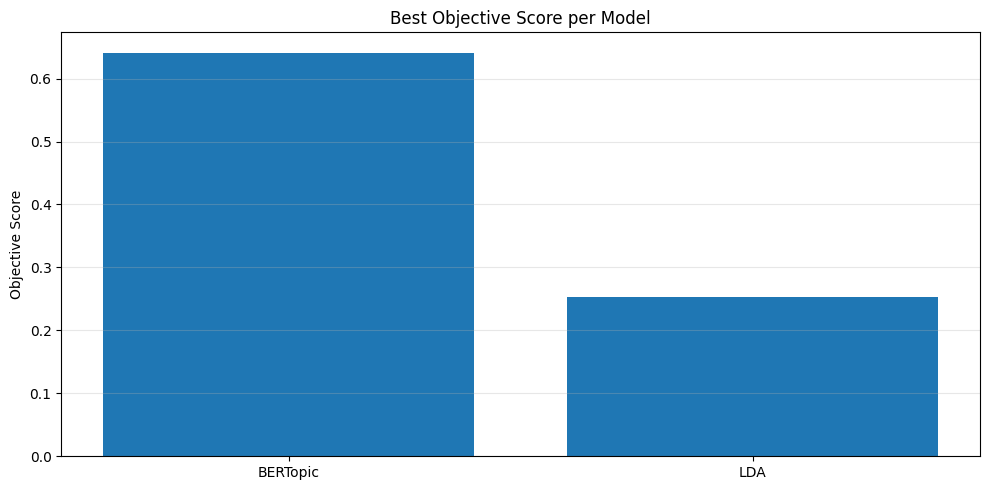

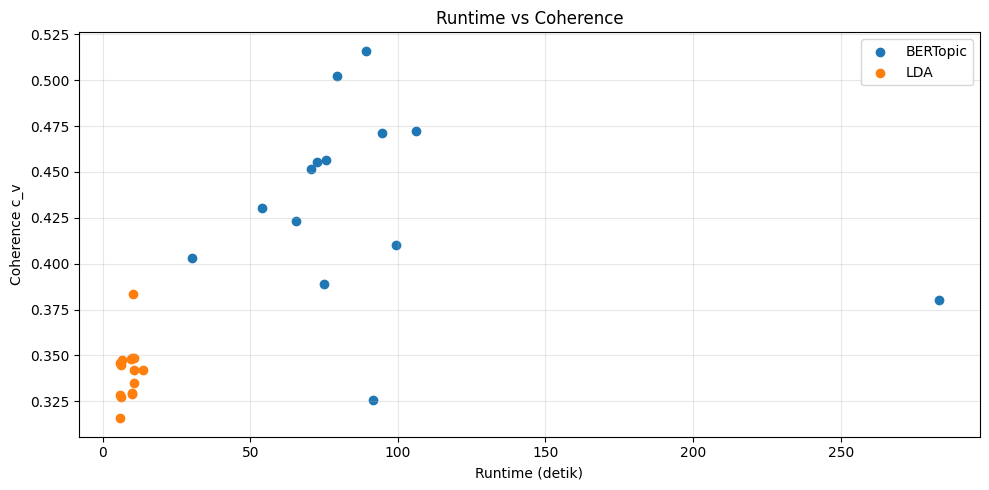

Menjalankan DTA sekali untuk best BERTopic...


9it [02:31, 16.86s/it]


Total baris DTA best BERTopic: 62


,Topic,Words,Frequency,Timestamp
0,0,"pendukung keputusan, kesehatan tanah, kinerja,...",16,2018
1,0,"program kerja, produksi, kinerja, blocplan, di...",10,2019
2,0,"organisasi, tanaman hidroponik, hidroponik pin...",5,2020
3,0,"website, risiko, universitas jenderal, unsoed,...",12,2021
4,0,"pengelolaan studi, teknik, arsitektur, mobil, ...",21,2022
5,0,"desa, mandiri mocaf, monitoring, berhasil, pro...",19,2023
6,0,"berbasis website, rekomendasi, kinerja, implem...",48,2024
7,0,"laravel, performa, implementasi, berbasis webs...",63,2025
8,0,"implementasi, performa, kinerja, laravel, eval...",19,2026
9,1,"penjualan, bus, berbasis web, waterfall, trans...",17,2018


In [ ]:
def get_ok_rows(df):
    if df.empty:
        return df
    return df[df["status"] == "ok"].copy()


def _to_numeric(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def _minmax_norm(series):
    values = pd.to_numeric(series, errors="coerce")
    cmin = values.min()
    cmax = values.max()
    if pd.isna(cmin) or pd.isna(cmax) or cmin == cmax:
        return pd.Series(0.5, index=values.index, dtype=float)
    return (values - cmin) / (cmax - cmin)


bertopic_ok = get_ok_rows(bertopic_results_df)
lda_ok = get_ok_rows(lda_results_df)

metric_cols = [
    "objective_score",
    "coherence_cv",
    "topic_diversity",
    "runtime_seconds",
    "num_topics",
    "num_outliers",
    "outlier_pct",
]

if not bertopic_ok.empty:
    bertopic_ok = _to_numeric(bertopic_ok, metric_cols)

    stage_priority_map = {
        "rerank_reduce_outliers": 0,
        "single_pass": 1,
        "screening": 2,
    }
    if "stage" in bertopic_ok.columns:
        bertopic_ok["_stage_priority"] = bertopic_ok["stage"].map(stage_priority_map).fillna(99).astype(int)
    else:
        bertopic_ok["_stage_priority"] = 99

    bertopic_ok = (
        bertopic_ok
        .sort_values(
            ["scenario_id", "_stage_priority", "objective_score", "coherence_cv", "topic_diversity", "runtime_seconds"],
            ascending=[True, True, False, False, False, True],
            na_position="last",
        )
        .drop_duplicates(subset=["scenario_id"], keep="first")
        .drop(columns=["_stage_priority"], errors="ignore")
        .reset_index(drop=True)
    )

if not lda_ok.empty:
    lda_ok = _to_numeric(lda_ok, metric_cols)

leaderboard_parts = []

if not bertopic_ok.empty:
    tmp_b = pd.DataFrame(
        {
            "model": "BERTopic",
            "scenario_id": bertopic_ok.get("scenario_id"),
            "scenario_source": bertopic_ok.get("scenario_source"),
            "selection_stage": bertopic_ok.get("stage", "single_pass"),
            "objective_score": bertopic_ok.get("objective_score"),
            "coherence_cv": bertopic_ok.get("coherence_cv"),
            "topic_diversity": bertopic_ok.get("topic_diversity"),
            "runtime_seconds": bertopic_ok.get("runtime_seconds"),
            "num_topics": bertopic_ok.get("num_topics"),
            "num_outliers": bertopic_ok.get("num_outliers"),
            "outlier_pct": bertopic_ok.get("outlier_pct"),
        }
    )
    leaderboard_parts.append(tmp_b)

if not lda_ok.empty:
    tmp_l = pd.DataFrame(
        {
            "model": "LDA",
            "scenario_id": lda_ok.get("scenario_id"),
            "scenario_source": lda_ok.get("scenario_source"),
            "selection_stage": "single_pass",
            "objective_score": lda_ok.get("objective_score"),
            "coherence_cv": lda_ok.get("coherence_cv"),
            "topic_diversity": lda_ok.get("topic_diversity"),
            "runtime_seconds": lda_ok.get("runtime_seconds"),
            "num_topics": lda_ok.get("num_topics"),
            "num_outliers": np.nan,
            "outlier_pct": np.nan,
        }
    )
    leaderboard_parts.append(tmp_l)

if leaderboard_parts:
    leaderboard_raw_df = pd.concat(leaderboard_parts, ignore_index=True)

    for col in [
        "objective_score",
        "coherence_cv",
        "topic_diversity",
        "runtime_seconds",
        "num_topics",
        "num_outliers",
        "outlier_pct",
    ]:
        if col in leaderboard_raw_df.columns:
            leaderboard_raw_df[col] = pd.to_numeric(leaderboard_raw_df[col], errors="coerce")

    norm_df = leaderboard_raw_df.copy()
    norm_df["objective_norm"] = _minmax_norm(norm_df["objective_score"])
    norm_df["coherence_cv_norm"] = _minmax_norm(norm_df["coherence_cv"])
    norm_df["topic_diversity_norm"] = _minmax_norm(norm_df["topic_diversity"])
    norm_df["runtime_norm"] = 1 - _minmax_norm(norm_df["runtime_seconds"])

    norm_df["pareto_score"] = (
        0.45 * norm_df["objective_norm"]
        + 0.25 * norm_df["coherence_cv_norm"]
        + 0.20 * norm_df["topic_diversity_norm"]
        + 0.10 * norm_df["runtime_norm"]
    )

    ranking_df = norm_df.sort_values(
        ["pareto_score", "objective_score", "coherence_cv", "topic_diversity", "runtime_seconds"],
        ascending=[False, False, False, False, True],
        na_position="last",
    ).reset_index(drop=True)

    ranking_df["rank_overall"] = np.arange(1, len(ranking_df) + 1)
    ranking_df["rank_in_model"] = ranking_df.groupby("model").cumcount() + 1

    leaderboard_df = ranking_df[
        [
            "rank_overall",
            "rank_in_model",
            "model",
            "scenario_id",
            "scenario_source",
            "selection_stage",
            "pareto_score",
            "objective_score",
            "coherence_cv",
            "topic_diversity",
            "runtime_seconds",
            "num_topics",
            "num_outliers",
            "outlier_pct",
        ]
    ].copy()

    best_model_df = (
        leaderboard_df[leaderboard_df["rank_in_model"] == 1]
        .copy()
        .rename(columns={"scenario_id": "best_scenario"})
    )[
        [
            "model",
            "best_scenario",
            "rank_overall",
            "pareto_score",
            "objective_score",
            "coherence_cv",
            "topic_diversity",
            "runtime_seconds",
            "num_topics",
        ]
    ]

    print("Ranking perbandingan (ringkas):")
    display(leaderboard_df.head(20))
    print("Best per model:")
    display(best_model_df)

    plt.figure(figsize=(10, 5))
    if sns is not None:
        sns.barplot(data=best_model_df, x="model", y="objective_score")
    else:
        plt.bar(best_model_df["model"], best_model_df["objective_score"])

    plt.title("Best Objective Score per Model")
    plt.ylabel("Objective Score")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    if sns is not None:
        sns.scatterplot(data=leaderboard_df, x="runtime_seconds", y="coherence_cv", hue="model")
    else:
        for model_name in leaderboard_df["model"].dropna().unique():
            subset = leaderboard_df[leaderboard_df["model"] == model_name]
            plt.scatter(subset["runtime_seconds"], subset["coherence_cv"], label=model_name)
        plt.legend()
    plt.title("Runtime vs Coherence")
    plt.xlabel("Runtime (detik)")
    plt.ylabel("Coherence c_v")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    leaderboard_df = pd.DataFrame()
    norm_df = pd.DataFrame()
    best_model_df = pd.DataFrame()
    print("Belum ada hasil sukses untuk dibandingkan.")

# DTA dijalankan sekali setelah best BERTopic ditemukan (bukan per skenario).
best_bertopic_dta_df = pd.DataFrame()
best_bertopic_dta_records = []

if best_bertopic_payload is None:
    print("DTA best BERTopic dilewati: best payload belum tersedia.")
elif timestamps is None:
    print("DTA best BERTopic dilewati: timestamps tidak tersedia.")
else:
    print("Menjalankan DTA sekali untuk best BERTopic...")
    try:
        dta_df = best_bertopic_payload["trainer"].model.topics_over_time(
            bertopic_docs,
            timestamps=timestamps,
        )
        if dta_df.empty:
            print("DTA selesai, tetapi hasil kosong.")
        else:
            sort_cols = [col for col in ["Topic", "Timestamp"] if col in dta_df.columns]
            if sort_cols:
                best_bertopic_dta_df = dta_df.sort_values(by=sort_cols).reset_index(drop=True)
            else:
                best_bertopic_dta_df = dta_df.reset_index(drop=True)

            best_bertopic_dta_records = best_bertopic_dta_df.to_dict(orient="records")
            print("Total baris DTA best BERTopic:", len(best_bertopic_dta_df))
            display(best_bertopic_dta_df.head(20))
    except Exception as exc:
        print("DTA best BERTopic gagal:", exc)

## 10. Visualisasi Topik dan Word Cloud (BERTopic & LDA)
Bangun visualisasi jumlah dokumen per topik, representasi top words, dan word cloud agregat untuk model BERTopic maupun LDA terbaik.

=== Visualisasi BERTopic ===


,Topic,Count,Name
0,0,213,0_laravel_implementasi_kinerja_berbasis website
1,1,103,1_penjualan_umkm_transaksi_berbasis website
2,2,41,2_desa_dinas_berbasis web_administrasi
3,3,29,3_algoritma_thalassemia_resnet_performa
4,4,24,4_game edukasi_pembelajaran_pemain_pengembanga...
5,5,22,5_analisis sentimen_naïve_naïve bayes_negatif
6,6,14,6_objek wisata_limbasari_web_homestay budaya
7,7,13,7_precision_bahasa isyarat_mendeteksi_karies
8,8,14,8_pegawai_kampung marketer_mitra statistik_kelola


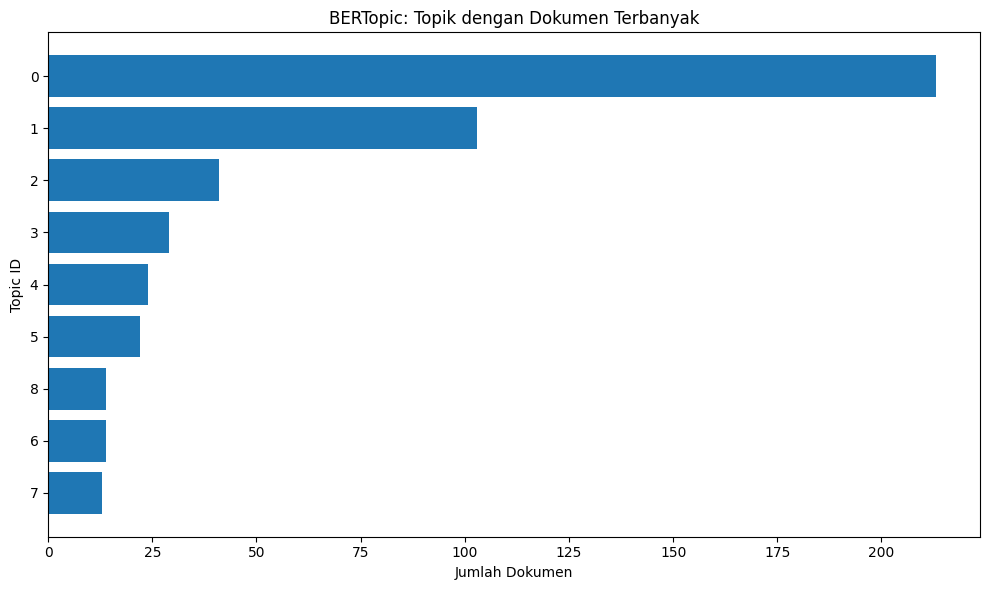

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'color': '#D55E00'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.0062740128354103145, 0.006292224365131128,
                    0.006467208181277041, 0.007007148347846324,
                    0.007012501792627082, 0.008098179028540717,
                    0.008485479779797578, 0.008896810638036937,
                    0.010065534635346094, 0.010348282257459391],
              'xaxis': 'x',
              'y': [pendukung keputusan  , produk  , unsoed  , evaluasi  ,
                    universitas jenderal  , pengelolaan  , berbasis website  ,
                    kinerja  , implementasi  , laravel  ],
              'yaxis': 'y'},
             {'marker': {'color': '#0072B2'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.01131570010175497, 0.011793569917256485,
                    0.011880934913038007, 0.012447210998130877,
                    0.012562024955486634, 0.012821304727860111,
                    0.013048443456714978, 0.01540498616606762, 0.01815392733931714,
                    0.023607202699249895],
              'xaxis': 'x2',
              'y': [purbalingga  , produk  , pengembangan waterfall  , dibangun  ,
                    pemrograman php  , pengelolaan  , berbasis website  , transaksi
                    , umkm  , penjualan  ],
              'yaxis': 'y2'},
             {'marker': {'color': '#CC79A7'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.014210124724601725, 0.01496533340682657,
                    0.014988777407214235, 0.0154021058939716, 0.01690900191273637,
                    0.01811514960576876, 0.023986593043056486,
                    0.025743279236578435, 0.027910053631789677,
                    0.028838420636421513],
              'xaxis': 'x3',
              'y': [perpustakaan  , administrasi kependudukan  , informasi
                    pengelolaan  , rapat  , perjalanan dinas  , kabupaten
                    purbalingga  , administrasi  , berbasis web  , dinas  , desa  ],
              'yaxis': 'y3'},
             {'marker': {'color': '#E69F00'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.009214211767914548, 0.009369665877741188,
                    0.009536249200060944, 0.01032975531461112, 0.01109887655378642,
                    0.011421770239210469, 0.014115759655228979,
                    0.014580455322552376, 0.01583727993684951, 0.01635401125703488],
              'xaxis': 'x4',
              'y': [gempa bumi  , backpropagation  , clustering  , inceptionv3  ,
                    deteksi  , latency  , performa  , resnet  , thalassemia  ,
                    algoritma  ],
              'yaxis': 'y4'},
             {'marker': {'color': '#56B4E9'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.013437493331888782, 0.013986300602372763,
                    0.014096220038663397, 0.015418143788602517,
                    0.015418143788602517, 0.015458542771043582,
                    0.01607026505634497, 0.016574189219029072, 0.03728404583766272,
                    0.05371454296621072],
              'xaxis': 'x5',
              'y': [development  , materi  , unity  , game development  , npc  ,
                    development life  , pengembangan game  , pemain  , pembelajaran
                    , game edukasi  ],
              'yaxis': 'y5'},
             {'marker': {'color': '#009E73'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.014061009764747072, 0.014067240493154212,
                    0.017393341062209952, 0.017806821585108712,
                    0.01807917630621828, 0.021268866638332124,
                    0.024400715587895038, 0.03281829212985747,
                    0.033489263796670964, 0.036486078926487676],
              'xaxis': 'x6',
              'y': [support vector  , algoritma naïve  , stemming  ,

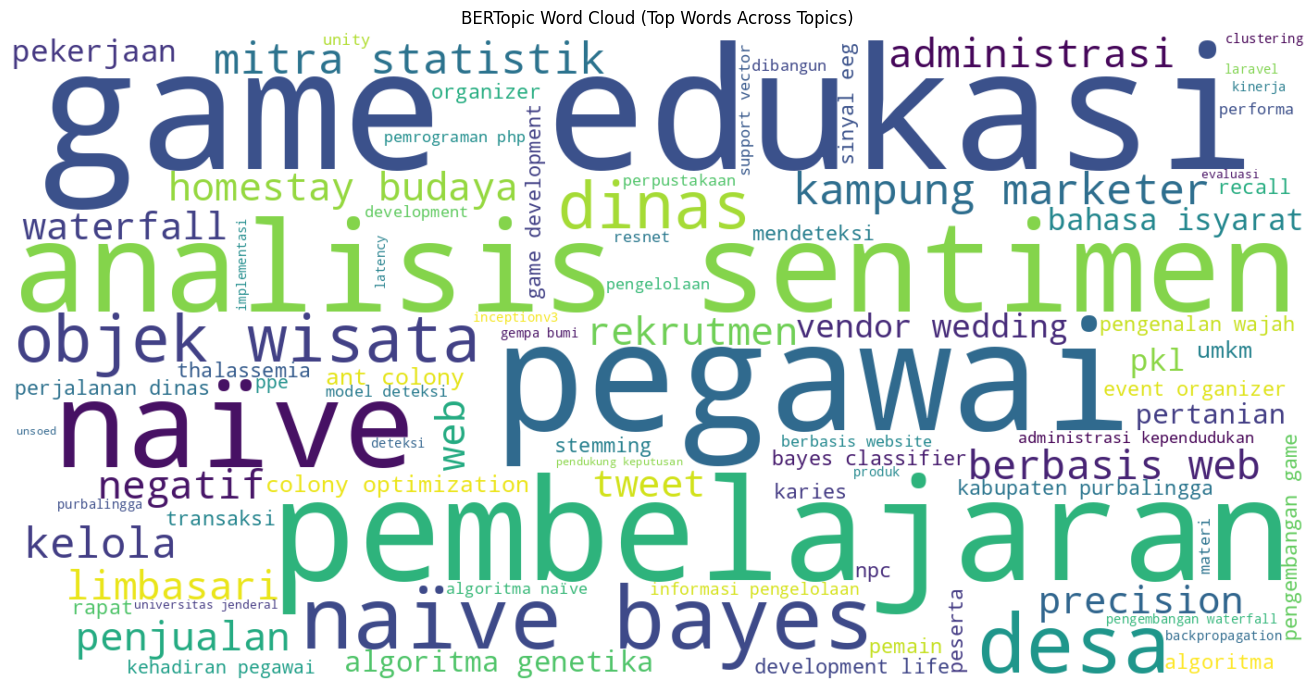


=== Visualisasi LDA ===


,topic_id,top_words
0,0,"model, nilai, siswa, aplikasi, tingkat, deteks..."
1,1,"game, prediksi, nilai, ajar, model, edukasi, m..."
2,2,"kelola, aplikasi, kerja, web, rancang, usaha, ..."
3,3,"pakar, sakit, pegawai, identifikasi, sampah, b..."
4,4,"aplikasi, desa, layan, cepat, tingkat, laravel..."
5,5,"nilai, putus, tentu, rekomendasi, model, dukun..."
6,6,"barang, kelola, lapor, dinas, tani, tingkat, j..."
7,7,"tingkat, implementasi, aplikasi, fitur, integr..."


IndexError: index 1194 is out of bounds for axis 1 with size 1194

In [ ]:
from collections import Counter

try:
    from wordcloud import WordCloud
except Exception as exc:
    WordCloud = None
    print("[WARN] wordcloud tidak tersedia:", exc)

try:
    nbformat_module = __import__("nbformat")
    nbformat_parts = str(getattr(nbformat_module, "__version__", "0.0")).split(".")
    nbformat_major = int(nbformat_parts[0]) if len(nbformat_parts) > 0 else 0
    nbformat_minor = int(nbformat_parts[1]) if len(nbformat_parts) > 1 else 0
    NBFORMAT_OK = (nbformat_major, nbformat_minor) >= (4, 2)
except Exception:
    NBFORMAT_OK = False

VIS_TOPICS_LIMIT = 15
VIS_WORDS_PER_TOPIC = 15
WORDCLOUD_MAX_WORDS = 200
WORDCLOUD_SIZE = (1400, 700)


def _plot_wordcloud_from_freq(freq_map, title):
    if WordCloud is None:
        print(f"Word cloud '{title}' dilewati: package wordcloud tidak tersedia.")
        return
    if not freq_map:
        print(f"Word cloud '{title}' dilewati: frekuensi kata kosong.")
        return

    wc = WordCloud(
        width=WORDCLOUD_SIZE[0],
        height=WORDCLOUD_SIZE[1],
        background_color="white",
        colormap="viridis",
        max_words=WORDCLOUD_MAX_WORDS,
    ).generate_from_frequencies(freq_map)

    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def _safe_display_plotly_figure(fig, chart_name):
    if fig is None:
        return
    if not NBFORMAT_OK:
        print(f"{chart_name} dilewati: nbformat>=4.2.0 tidak tersedia di kernel.")
        return
    try:
        display(fig)
    except Exception as exc:
        print(f"{chart_name} dilewati:", exc)


def _bertopic_word_freq(model, top_n_words=15):
    freq = {}
    for topic_id, word_scores in (model.get_topics() or {}).items():
        if int(topic_id) == -1:
            continue
        for word, score in (word_scores or [])[:top_n_words]:
            score_value = float(score or 0.0)
            if score_value <= 0:
                continue
            freq[word] = max(freq.get(word, 0.0), score_value)
    return freq


def _lda_word_freq(model, top_n_words=15):
    freq = {}
    for topic_id in range(model.num_topics):
        for word, score in model.show_topic(topic_id, topn=top_n_words):
            score_value = float(score or 0.0)
            if score_value <= 0:
                continue
            freq[word] = max(freq.get(word, 0.0), score_value)
    return freq


print("=== Visualisasi BERTopic ===")
if best_bertopic_payload is None:
    print("Best BERTopic belum tersedia.")
else:
    best_bertopic_model = best_bertopic_payload["trainer"].model
    bertopic_info = best_bertopic_model.get_topic_info().copy()

    if "Topic" in bertopic_info.columns:
        bertopic_info = bertopic_info[bertopic_info["Topic"] != -1].copy()

    if bertopic_info.empty:
        print("Topik BERTopic kosong setelah filter outlier.")
    else:
        display_cols = [col for col in ["Topic", "Count", "Name"] if col in bertopic_info.columns]
        if not display_cols:
            display_cols = bertopic_info.columns.tolist()

        display(bertopic_info[display_cols].head(VIS_TOPICS_LIMIT))

        if "Count" in bertopic_info.columns:
            top_plot_df = (
                bertopic_info
                .nlargest(min(VIS_TOPICS_LIMIT, len(bertopic_info)), "Count")
                .sort_values("Count", ascending=True)
            )

            plt.figure(figsize=(10, 6))
            plt.barh(top_plot_df["Topic"].astype(str), top_plot_df["Count"], color="#1f77b4")
            plt.title("BERTopic: Topik dengan Dokumen Terbanyak")
            plt.xlabel("Jumlah Dokumen")
            plt.ylabel("Topic ID")
            plt.tight_layout()
            plt.show()

        try:
            top_n_topics = max(1, min(VIS_TOPICS_LIMIT, len(bertopic_info)))
            bertopic_fig = best_bertopic_model.visualize_barchart(top_n_topics=top_n_topics, n_words=VIS_WORDS_PER_TOPIC)
            _safe_display_plotly_figure(bertopic_fig, "visualize_barchart BERTopic")
        except Exception as exc:
            print("visualize_barchart BERTopic dilewati:", exc)

        bertopic_freq = _bertopic_word_freq(best_bertopic_model, top_n_words=VIS_WORDS_PER_TOPIC)
        _plot_wordcloud_from_freq(bertopic_freq, "BERTopic Word Cloud (Top Words Across Topics)")

print("\n=== Visualisasi LDA ===")
if best_lda_payload is None:
    print("Best LDA belum tersedia.")
else:
    best_lda_trainer = best_lda_payload["trainer"]
    best_lda_model = best_lda_trainer.model
    trainer_dictionary = best_lda_trainer.dictionary

    lda_topic_rows = []
    for topic_id in range(best_lda_model.num_topics):
        topic_words = best_lda_model.show_topic(topic_id, topn=VIS_WORDS_PER_TOPIC)
        lda_topic_rows.append(
            {
                "topic_id": int(topic_id),
                "top_words": ", ".join([word for word, _ in topic_words]),
            }
        )

    lda_topic_df = pd.DataFrame(lda_topic_rows)
    display(lda_topic_df.head(VIS_TOPICS_LIMIT))

    lda_corpus_for_model = [
        trainer_dictionary.doc2bow(str(doc).split())
        for doc in lda_docs
    ]

    dominant_topic_ids = []
    failed_distribution_docs = 0

    for bow in lda_corpus_for_model:
        if not bow:
            continue
        try:
            distribution = best_lda_model.get_document_topics(bow, minimum_probability=0.0)
        except Exception:
            failed_distribution_docs += 1
            continue

        if distribution:
            dominant_topic_ids.append(int(max(distribution, key=lambda x: x[1])[0]))

    if failed_distribution_docs > 0:
        print(f"[WARN] {failed_distribution_docs} dokumen LDA dilewati saat hitung distribusi topik.")

    if dominant_topic_ids:
        topic_counts = Counter(dominant_topic_ids)
        lda_count_df = pd.DataFrame(
            {
                "topic_id": list(topic_counts.keys()),
                "doc_count": list(topic_counts.values()),
            }
        ).sort_values("doc_count", ascending=False)

        plt.figure(figsize=(10, 6))
        plt.bar(
            lda_count_df["topic_id"].astype(str),
            lda_count_df["doc_count"],
            color="#ff7f0e",
        )
        plt.title("LDA: Distribusi Dokumen per Topik Dominan")
        plt.xlabel("Topic ID")
        plt.ylabel("Jumlah Dokumen")
        plt.tight_layout()
        plt.show()

    lda_freq = _lda_word_freq(best_lda_model, top_n_words=VIS_WORDS_PER_TOPIC)
    _plot_wordcloud_from_freq(lda_freq, "LDA Word Cloud (Top Words Across Topics)")

## 11. Simpan CSV per Step Preprocessing untuk Laporan
Ekspor ringkas per tahap (raw tervalidasi, hasil preprocessing model-ready, dan summary) ke CSV agar mudah dipakai untuk analisis fenomena di skripsi.

In [ ]:
report_ts = datetime.now().strftime("%Y%m%d-%H%M%S")

preprocess_step_paths = {}
preprocess_step_summary_rows = []


def _existing_cols(df: pd.DataFrame, candidate_cols: list[str]) -> list[str]:
    return [col for col in candidate_cols if col in df.columns]


def _token_count(series: pd.Series) -> pd.Series:
    return series.fillna("").astype(str).str.split().apply(len)


# Step 1: data raw/processed yang sudah dinormalisasi + lolos validasi awal
source_text_col = None
if "text_col_for_validation" in globals() and text_col_for_validation in source_df.columns:
    source_text_col = text_col_for_validation
else:
    source_text_col = next(
        (col for col in ["abstract", "combined_text", "cleaned_text", "processed_text"] if col in source_df.columns),
        None,
    )

step1_cols = _existing_cols(source_df, ["id", "title", "year"])
step1_df = source_df[step1_cols].copy()
if source_text_col is not None:
    step1_df["text_validated"] = source_df[source_text_col].fillna("").astype(str)
    step1_df["token_count_raw"] = _token_count(step1_df["text_validated"])

step1_path = ARTIFACTS_DIR / f"preprocess_step1_normalized_validated_{report_ts}.csv"
step1_df.to_csv(step1_path, index=False)
preprocess_step_paths["step1_normalized_validated"] = str(step1_path)
preprocess_step_summary_rows.append(
    {
        "step": "step1_normalized_validated",
        "n_rows": int(len(step1_df)),
        "n_columns": int(step1_df.shape[1]),
        "output_csv": str(step1_path),
    }
)

# Step 2: data model-ready (hasil preprocessing BERTopic/LDA)
step2_cols = _existing_cols(working_df, ["id", "title", "year", "cleaned_text", "processed_text"])
if not step2_cols:
    step2_cols = list(working_df.columns)

step2_df = working_df[step2_cols].copy()
if "cleaned_text" in step2_df.columns:
    step2_df["cleaned_token_count"] = _token_count(step2_df["cleaned_text"])
if "processed_text" in step2_df.columns:
    step2_df["processed_token_count"] = _token_count(step2_df["processed_text"])

step2_path = ARTIFACTS_DIR / f"preprocess_step2_model_ready_{report_ts}.csv"
step2_df.to_csv(step2_path, index=False)
preprocess_step_paths["step2_model_ready"] = str(step2_path)
preprocess_step_summary_rows.append(
    {
        "step": "step2_model_ready",
        "n_rows": int(len(step2_df)),
        "n_columns": int(step2_df.shape[1]),
        "output_csv": str(step2_path),
    }
)

# Step 3: ringkasan minimal untuk tabel fenomena skripsi
step3_cols = _existing_cols(step2_df, ["id", "title", "year", "cleaned_token_count", "processed_token_count"])
if not step3_cols:
    step3_cols = list(step2_df.columns)

step3_df = step2_df[step3_cols].copy()
step3_path = ARTIFACTS_DIR / f"preprocess_step3_thesis_summary_{report_ts}.csv"
step3_df.to_csv(step3_path, index=False)
preprocess_step_paths["step3_thesis_summary"] = str(step3_path)
preprocess_step_summary_rows.append(
    {
        "step": "step3_thesis_summary",
        "n_rows": int(len(step3_df)),
        "n_columns": int(step3_df.shape[1]),
        "output_csv": str(step3_path),
    }
)

# Ringkasan semua step preprocessing
preprocess_steps_summary_df = pd.DataFrame(preprocess_step_summary_rows)
preprocess_steps_summary_path = ARTIFACTS_DIR / f"preprocess_steps_summary_{report_ts}.csv"
preprocess_steps_summary_df.to_csv(preprocess_steps_summary_path, index=False)
preprocess_step_paths["steps_summary"] = str(preprocess_steps_summary_path)

print("CSV preprocessing per step tersimpan:")
for step_name, csv_path in preprocess_step_paths.items():
    print(f"- {step_name}: {csv_path}")

print("\nPreview step2_model_ready:")
display(step2_df.head(10))

print("Ringkasan step preprocessing:")
display(preprocess_steps_summary_df)

: 

## 12. Simpan Best Config, Model, DTA Best BERTopic, dan Tabel Hasil Ringkas
Simpan hasil tuning dan ranking perbandingan ke file dengan kolom penting saja agar output final tetap rapi dan fokus.

In [ ]:
run_ts = datetime.now().strftime("%Y%m%d-%H%M%S")

bertopic_csv_path = ARTIFACTS_DIR / f"bertopic_tuning_{run_ts}.csv"
lda_csv_path = ARTIFACTS_DIR / f"lda_tuning_{run_ts}.csv"
combined_csv_path = ARTIFACTS_DIR / f"comparison_ranking_{run_ts}.csv"
combined_parquet_path = ARTIFACTS_DIR / f"comparison_ranking_{run_ts}.parquet"
best_bertopic_dta_csv_path = ARTIFACTS_DIR / f"best_bertopic_dta_{run_ts}.csv"
best_config_path = ARTIFACTS_DIR / f"best_config_{run_ts}.json"
best_model_path = ARTIFACTS_DIR / f"best_model_paths_{run_ts}.json"
fallback_models_dir = ARTIFACTS_DIR / "saved_models"
fallback_models_dir.mkdir(parents=True, exist_ok=True)


def to_serializable(obj):
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serializable(v) for v in obj]
    if isinstance(obj, tuple):
        return [to_serializable(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def write_json(path: Path, payload: dict):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(to_serializable(payload), f, ensure_ascii=False, indent=2)


def _select_existing_columns(df: pd.DataFrame, preferred_cols: list[str]) -> pd.DataFrame:
    existing_cols = [col for col in preferred_cols if col in df.columns]
    if not existing_cols:
        return df.copy()
    return df[existing_cols].copy()


def save_bertopic_with_fallback(trainer, job_id: str) -> str:
    try:
        return trainer.save_model(job_id)
    except PermissionError as exc:
        fallback_dir = fallback_models_dir / f"bertopic_{job_id}"
        fallback_dir.mkdir(parents=True, exist_ok=True)

        model_path = str(fallback_dir / "model")
        trainer.model.save(model_path, serialization="safetensors", save_ctfidf=True)

        if getattr(trainer, "embeddings", None) is not None:
            np.save(str(fallback_dir / "embeddings.npy"), trainer.embeddings)

        metadata = {
            "job_id": job_id,
            "model_type": "bertopic",
            "save_mode": "fallback_notebook",
            "reason": str(exc),
            "saved_at": datetime.now().isoformat(),
            "hyperparameters": trainer.params.model_dump(),
        }
        write_json(fallback_dir / "metadata.json", metadata)

        print(f"[WARN] Gagal simpan BERTopic ke path default. Fallback ke: {fallback_dir}")
        return str(fallback_dir)


def save_lda_with_fallback(trainer, job_id: str) -> str:
    try:
        return trainer.save_model(job_id)
    except PermissionError as exc:
        fallback_dir = fallback_models_dir / f"lda_{job_id}"
        fallback_dir.mkdir(parents=True, exist_ok=True)

        trainer.model.save(str(fallback_dir / "lda_model"))
        trainer.dictionary.save(str(fallback_dir / "dictionary.dict"))

        metadata = {
            "job_id": job_id,
            "model_type": "lda",
            "save_mode": "fallback_notebook",
            "reason": str(exc),
            "saved_at": datetime.now().isoformat(),
            "hyperparameters": trainer.params.model_dump(),
        }
        write_json(fallback_dir / "metadata.json", metadata)

        print(f"[WARN] Gagal simpan LDA ke path default. Fallback ke: {fallback_dir}")
        return str(fallback_dir)


if "leaderboard_df" not in globals() or leaderboard_df is None:
    leaderboard_df = pd.DataFrame()

if "best_bertopic_dta_df" not in globals() or best_bertopic_dta_df is None:
    best_bertopic_dta_df = pd.DataFrame()

bertopic_export_cols = [
    "scenario_id",
    "scenario_source",
    "stage",
    "selection_mode",
    "status",
    "objective_score",
    "coherence_cv",
    "topic_diversity",
    "runtime_seconds",
    "num_topics",
    "num_outliers",
    "outlier_pct",
    "reduce_outliers_active",
    "screening_objective_score",
    "error",
]

lda_export_cols = [
    "scenario_id",
    "scenario_source",
    "status",
    "objective_score",
    "coherence_cv",
    "topic_diversity",
    "runtime_seconds",
    "num_topics",
    "error",
]

ranking_export_cols = [
    "rank_overall",
    "rank_in_model",
    "model",
    "scenario_id",
    "scenario_source",
    "selection_stage",
    "pareto_score",
    "objective_score",
    "coherence_cv",
    "topic_diversity",
    "runtime_seconds",
    "num_topics",
    "num_outliers",
    "outlier_pct",
]

bertopic_export_df = _select_existing_columns(bertopic_results_df, bertopic_export_cols)
lda_export_df = _select_existing_columns(lda_results_df, lda_export_cols)

bertopic_export_df.to_csv(bertopic_csv_path, index=False)
lda_export_df.to_csv(lda_csv_path, index=False)

if not leaderboard_df.empty:
    ranking_export_df = _select_existing_columns(leaderboard_df, ranking_export_cols)
    ranking_export_df.to_csv(combined_csv_path, index=False)

    try:
        ranking_export_df.to_parquet(combined_parquet_path, index=False)
        parquet_saved = True
    except Exception as parquet_exc:
        parquet_saved = False
        print("Simpan parquet dilewati:", parquet_exc)
else:
    ranking_export_df = pd.DataFrame()
    parquet_saved = False

if not best_bertopic_dta_df.empty:
    dta_export_cols = [col for col in ["Topic", "Timestamp", "Frequency", "Words"] if col in best_bertopic_dta_df.columns]
    if dta_export_cols:
        best_bertopic_dta_df[dta_export_cols].to_csv(best_bertopic_dta_csv_path, index=False)
    else:
        best_bertopic_dta_df.to_csv(best_bertopic_dta_csv_path, index=False)

best_config_payload = {
    "timestamp": run_ts,
    "best_bertopic": None,
    "best_lda": None,
    "best_bertopic_dta_rows": int(len(best_bertopic_dta_df)) if not best_bertopic_dta_df.empty else 0,
    "comparison_top10": ranking_export_df.head(10).to_dict(orient="records") if not ranking_export_df.empty else [],
}

if best_bertopic_payload is not None:
    best_bertopic_params = best_bertopic_payload.get("params_used")
    if best_bertopic_params is None:
        best_bertopic_params = best_bertopic_payload["scenario"]["params"]

    best_config_payload["best_bertopic"] = {
        "scenario_id": best_bertopic_payload["scenario"]["scenario_id"],
        "selection_stage": best_bertopic_payload.get("stage", "screening"),
        "params": best_bertopic_params.model_dump(),
        "metrics": best_bertopic_payload["metrics"],
    }

if best_lda_payload is not None:
    best_config_payload["best_lda"] = {
        "scenario_id": best_lda_payload["scenario"]["scenario_id"],
        "params": best_lda_payload["scenario"]["params"].model_dump(),
        "metrics": best_lda_payload["metrics"],
    }

write_json(best_config_path, best_config_payload)

saved_model_paths = {"bertopic": None, "lda": None}

if best_bertopic_payload is not None:
    bertopic_job_id = f"nb_best_bertopic_{run_ts}"
    saved_model_paths["bertopic"] = save_bertopic_with_fallback(best_bertopic_payload["trainer"], bertopic_job_id)

if best_lda_payload is not None:
    lda_job_id = f"nb_best_lda_{run_ts}"
    saved_model_paths["lda"] = save_lda_with_fallback(best_lda_payload["trainer"], lda_job_id)

write_json(best_model_path, saved_model_paths)

print("Artifacts tersimpan (kolom ringkas):")
print("-", bertopic_csv_path)
print("-", lda_csv_path)
if not ranking_export_df.empty:
    print("-", combined_csv_path)
if parquet_saved:
    print("-", combined_parquet_path)
if not best_bertopic_dta_df.empty:
    print("-", best_bertopic_dta_csv_path)
print("-", best_config_path)
print("-", best_model_path)
print("Fallback model dir:", fallback_models_dir)
print("Model storage path:", saved_model_paths)

if "preprocess_step_paths" in globals() and isinstance(preprocess_step_paths, dict) and preprocess_step_paths:
    print("Preprocessing CSV per step:")
    for step_name, csv_path in preprocess_step_paths.items():
        print(f"- {step_name}: {csv_path}")

: 

## 13. Uji Inference Singkat dengan Model Terbaik
Lakukan prediksi topik pada beberapa teks contoh untuk validasi cepat sebelum integrasi ke website.

In [ ]:
sample_texts = [
    "Sistem rekomendasi berbasis machine learning untuk pemilihan topik skripsi mahasiswa.",
    "Implementasi website monitoring kualitas udara menggunakan sensor IoT dan dashboard interaktif.",
    "Perbandingan performa model deep learning untuk klasifikasi sentimen bahasa Indonesia.",
]

INFERENCE_TOP_WORDS_PREVIEW = 15

if best_bertopic_payload is None and best_lda_payload is None:
    print("Belum ada model terbaik yang bisa diuji inference.")

if best_bertopic_payload is not None:
    best_bertopic_model = best_bertopic_payload["trainer"].model
    bertopic_inputs = [preprocessor.preprocess_cleaned(t) for t in sample_texts]
    raw_topics, _ = best_bertopic_model.transform(bertopic_inputs)
    raw_topics = [int(t) for t in raw_topics]

    adjusted_topics = raw_topics.copy()
    fallback_methods = ["direct_transform"] * len(adjusted_topics)

    if any(t == -1 for t in adjusted_topics):
        try:
            reduced = best_bertopic_model.reduce_outliers(
                bertopic_inputs,
                adjusted_topics,
                strategy="distributions",
            )
            reduced = [int(t) for t in reduced]
            for i, (before_t, after_t) in enumerate(zip(adjusted_topics, reduced)):
                if before_t == -1 and after_t != -1:
                    fallback_methods[i] = "reduce_outliers_distributions"
            adjusted_topics = reduced
        except Exception as exc:
            if "No outliers to reduce" not in str(exc):
                print("[WARN] reduce_outliers(distributions) gagal:", exc)

    if any(t == -1 for t in adjusted_topics):
        try:
            reduced = best_bertopic_model.reduce_outliers(
                bertopic_inputs,
                adjusted_topics,
                strategy="embeddings",
            )
            reduced = [int(t) for t in reduced]
            for i, (before_t, after_t) in enumerate(zip(adjusted_topics, reduced)):
                if before_t == -1 and after_t != -1:
                    fallback_methods[i] = "reduce_outliers_embeddings"
            adjusted_topics = reduced
        except Exception as exc:
            if "No outliers to reduce" not in str(exc):
                print("[WARN] reduce_outliers(embeddings) gagal:", exc)

    bertopic_infer_rows = []
    for text, query_text, raw_topic_id, topic_id, method in zip(
        sample_texts,
        bertopic_inputs,
        raw_topics,
        adjusted_topics,
        fallback_methods,
    ):
        topic_id = int(topic_id)
        fallback_score = None

        if topic_id == -1:
            try:
                candidate_topics, candidate_scores = best_bertopic_model.find_topics(query_text, top_n=1)
                if candidate_topics:
                    topic_id = int(candidate_topics[0])
                    fallback_score = float(candidate_scores[0]) if candidate_scores else None
                    method = "find_topics_fallback"
            except Exception as exc:
                print("[WARN] find_topics fallback gagal:", exc)

        if topic_id == -1:
            top_words = "outlier"
        else:
            topic_words = best_bertopic_model.get_topic(topic_id) or []
            top_words = ", ".join([w for w, _ in topic_words[:INFERENCE_TOP_WORDS_PREVIEW]]) if topic_words else "(topic kosong)"

        bertopic_infer_rows.append(
            {
                "text": text,
                "raw_pred_topic_id": int(raw_topic_id),
                "final_pred_topic_id": int(topic_id),
                "was_outlier_raw": int(raw_topic_id) == -1,
                "fallback_method": method,
                "fallback_score": None if fallback_score is None else round(fallback_score, 4),
                "top_words": top_words,
            }
        )

    raw_outliers = sum(1 for t in raw_topics if int(t) == -1)
    unresolved_after_fallback = sum(1 for row in bertopic_infer_rows if int(row["final_pred_topic_id"]) == -1)
    print(
        f"Inference BERTopic: raw_outliers={raw_outliers}, unresolved_after_fallback={unresolved_after_fallback}"
    )
    display(pd.DataFrame(bertopic_infer_rows))

if best_lda_payload is not None:
    best_lda_trainer = best_lda_payload["trainer"]
    lda_inputs = [preprocessor.preprocess(t) for t in sample_texts]
    lda_tokens = [text.split() for text in lda_inputs]
    lda_bows = [best_lda_trainer.dictionary.doc2bow(tokens) for tokens in lda_tokens]

    lda_infer_rows = []
    for raw_text, bow in zip(sample_texts, lda_bows):
        distribution = best_lda_trainer.model.get_document_topics(bow, minimum_probability=0.0)
        top_topic, top_prob = max(distribution, key=lambda x: x[1])
        top_words = ", ".join(
            [w for w, _ in best_lda_trainer.model.show_topic(top_topic, topn=INFERENCE_TOP_WORDS_PREVIEW)]
        )

        lda_infer_rows.append(
            {
                "text": raw_text,
                "pred_topic_id": int(top_topic),
                "topic_probability": round(float(top_prob), 4),
                "top_words": top_words,
            }
        )

    print("Inference LDA:")
    display(pd.DataFrame(lda_infer_rows))

: 